<a href="https://colab.research.google.com/github/chrispchen/ChenHypoxia/blob/main/scRNA-seq%20preprocessing/PreprocessingAndQualityFiltering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Preprocessing and filtering

Importantly, all mentions of "anoxia" are mislabeled, they should all be "hypoxia".

## Load into AnnData


In [ ]:
# Mount google drive

from google.colab import drive
drive.mount('/content/drive/')
data_path = '/content/drive/MyDrive/Chris/All/'  #change dir to your project folder

Mounted at /content/drive/


## Environment Setup

Install software, load modules, configure workspace settings.

In [ ]:
# No editing of this code cell is required

# Environment Setup: verified working w/ Python 3.9.16 on 230316

# print python version to screen
!python --version

# pip install software
!pip install -q scanpy leidenalg==0.8.10 harmonypy==0.0.9 scrublet==0.2.3 pydeseq2 adjustText
!wget -qc https://raw.githubusercontent.com/wagnerde/scTools-py/master/scTools_dew.py   # tools by Dan are essential for this analysis

# import python packages
import os, sys
import numpy as np
import pandas as pd
import scanpy as sc
import scTools_dew as dew
import warnings


# set some ScanPy settings
sc.set_figure_params(dpi=120, figsize=[4,4], fontsize=7)
sc.settings.verbosity = 0

Python 3.12.13
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 56.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 114.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 647.5/647.5 kB 43.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 6.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 92.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━

In [ ]:
# The DGE_filtered folder contains the expression matrix, genes, and files
# NOTE: split-pipe versions older than 1.1.0 used 'DGE.mtx'
adata = sc.read_mtx(data_path + 'raw/count_matrix.mtx')

# reading in gene and cell data
gene_data = pd.read_csv(data_path + 'raw/all_genes.csv')
cell_meta = pd.read_csv(data_path + 'raw/cell_metadata.csv')

# find genes with nan values and filter
gene_data = gene_data[gene_data.gene_name.notnull()]
notNa = gene_data.index
notNa = notNa.to_list()

# remove genes with nan values and assign gene names
adata = adata[:,notNa]
adata.var = gene_data
adata.var.set_index('gene_name', inplace=True)
adata.var.index.name = None
adata.var_names_make_unique()

# add cell meta data to anndata object
adata.obs = cell_meta
adata.obs.set_index('bc_wells', inplace=True)
adata.obs.index.name = None
adata.obs_names_make_unique()

sc.pp.filter_cells(adata, min_genes=300)
sc.pp.filter_genes(adata, min_cells=5)

# Returns the dimensions of the expression matrix (cells, genes)
adata.shape

/usr/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/usr/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


(82322, 31655)

In [ ]:
adata.obs

,sample,species,gene_count,tscp_count,mread_count,bc1_wind,bc2_wind,bc3_wind,bc1_well,bc2_well,bc3_well,n_genes
13_01_40__s1,Anoxia_2hrs_WT_1,GRCZ11Law,818,1188,1814,13,1,40,B1,A1,D4,818
13_01_72__s1,Anoxia_2hrs_WT_1,GRCZ11Law,3647,15452,24677,13,1,72,B1,A1,F12,3647
13_02_35__s1,Anoxia_2hrs_WT_1,GRCZ11Law,2412,9247,14396,13,2,35,B1,A2,C11,2412
13_02_84__s1,Anoxia_2hrs_WT_1,GRCZ11Law,3791,18305,29743,13,2,84,B1,A2,G12,3791
13_02_85__s1,Anoxia_2hrs_WT_1,GRCZ11Law,400,702,1104,13,2,85,B1,A2,H1,400
...,...,...,...,...,...,...,...,...,...,...,...,...
24_95_13__s7,Reoxy_2hrs_WT_4,GRCZ11Law,1050,1535,2323,24,95,13,B12,H11,B1,1050
24_95_23__s7,Reoxy_2hrs_WT_4,GRCZ11Law,3174,10591,16948,24,95,23,B12,H11,B11,3174
24_95_47__s7,Reoxy_2hrs_WT_4,GRCZ11Law,502,669,1008,24,95,47,B12,H11,D11,502
24_95_62__s7,Reoxy_2hrs_WT_4,GRCZ11Law,2825,5464,8501,24,95,62,B12,H11,F2,2825


## Perform Quality Filtering

### Perform Cell Barcode Filtering


In [ ]:
# apply labels to adata

Samples = [
 'Anoxia_2hrs_WT_1',
 'Anoxia_2hrs_WT_2',
 'Anoxia_2hrs_WT_3',
 'Anoxia_2hrs_WT_4',
 'Normoxia_10hpf_WT_1',
 'Normoxia_10hpf_WT_2',
 'Normoxia_10hpf_WT_3',
 'Normoxia_10hpf_WT_4',
 'Normoxia_6hpf_WT_1',
 'Normoxia_6hpf_WT_2',
 'Normoxia_6hpf_WT_3',
 'Normoxia_6hpf_WT_4',
 'Normoxia_8hpf_WT_1',
 'Normoxia_8hpf_WT_2',
 'Normoxia_8hpf_WT_3',
 'Normoxia_8hpf_WT_4',
 'Reoxy_2hrs_WT_1',
 'Reoxy_2hrs_WT_2',
 'Reoxy_2hrs_WT_3',
 'Reoxy_2hrs_WT_4']

adata.obs['Group'] = adata.obs['sample'].str.rsplit('_', n=1).str[0]

adata.obs['Condition'] = adata.obs['sample'].str.split('_', n=1).str[0]

In [ ]:
# Create a dictionary to store the new AnnData objects
adata_dict = {}

# Iterate through the unique sample names
for sample in adata.obs['sample'].unique():
    # Subset the original adata based on the sample name
    adata_sample = adata[adata.obs['sample'] == sample].copy()

    # Store the new AnnData object in the dictionary
    adata_dict[sample] = adata_sample

In [ ]:
## Use thresholds
adata_dict['Anoxia_2hrs_WT_1'].uns['counts_thresh'] = 4500
adata_dict['Anoxia_2hrs_WT_2'].uns['counts_thresh'] = 4500
adata_dict['Anoxia_2hrs_WT_3'].uns['counts_thresh'] = 4500
adata_dict['Anoxia_2hrs_WT_4'].uns['counts_thresh'] = 4500
adata_dict['Normoxia_10hpf_WT_1'].uns['counts_thresh'] = 5000
adata_dict['Normoxia_10hpf_WT_2'].uns['counts_thresh'] = 5000
adata_dict['Normoxia_10hpf_WT_3'].uns['counts_thresh'] = 5000
adata_dict['Normoxia_10hpf_WT_4'].uns['counts_thresh'] = 5000
adata_dict['Normoxia_6hpf_WT_1'].uns['counts_thresh'] = 5000
adata_dict['Normoxia_6hpf_WT_2'].uns['counts_thresh'] = 5000
adata_dict['Normoxia_6hpf_WT_3'].uns['counts_thresh'] = 5000
adata_dict['Normoxia_6hpf_WT_4'].uns['counts_thresh'] = 5000
adata_dict['Normoxia_8hpf_WT_1'].uns['counts_thresh'] = 5000
adata_dict['Normoxia_8hpf_WT_2'].uns['counts_thresh'] = 5000
adata_dict['Normoxia_8hpf_WT_3'].uns['counts_thresh'] = 5000
adata_dict['Normoxia_8hpf_WT_4'].uns['counts_thresh'] = 5000
adata_dict['Reoxy_2hrs_WT_1'].uns['counts_thresh'] = 4500
adata_dict['Reoxy_2hrs_WT_2'].uns['counts_thresh'] = 4500
adata_dict['Reoxy_2hrs_WT_3'].uns['counts_thresh'] = 4500
adata_dict['Reoxy_2hrs_WT_4'].uns['counts_thresh'] = 4500

In [ ]:
adata_backup = adata.copy() # nice to have a backup

Anoxia_2hrs_WT_1


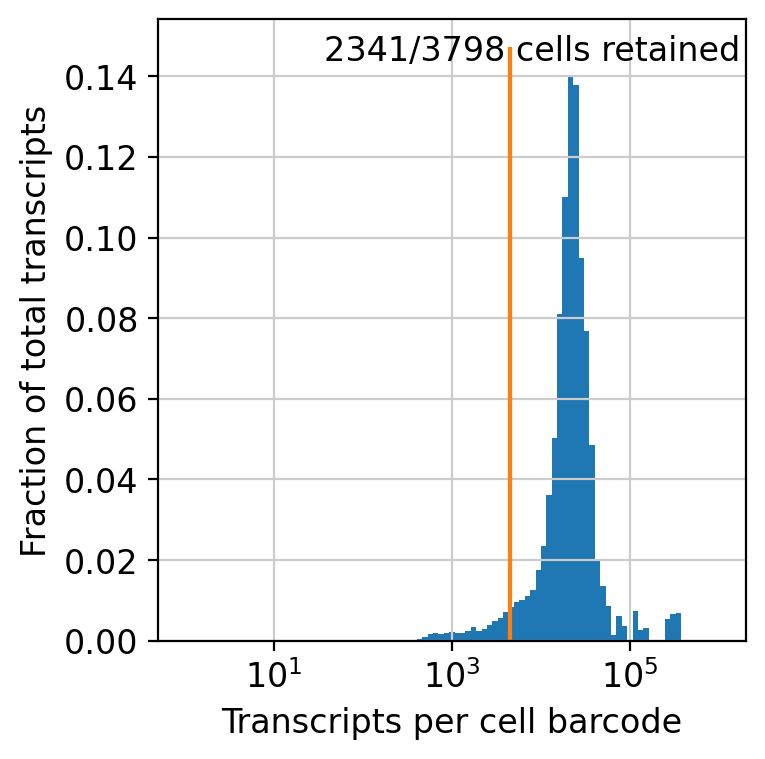

Barcode Filtering  (2341/3798 cells retained)

Anoxia_2hrs_WT_2


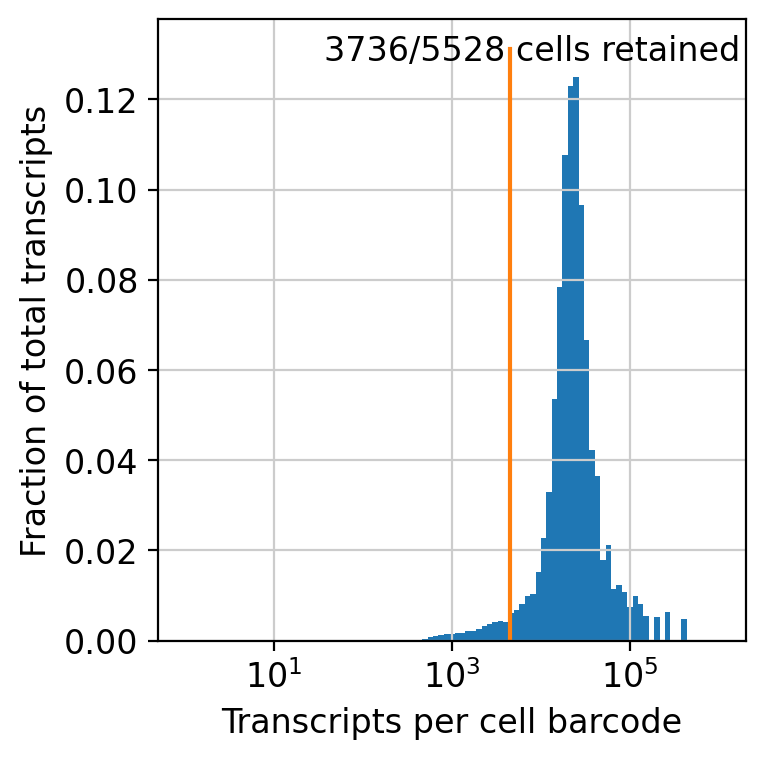

Barcode Filtering  (3736/5528 cells retained)

Anoxia_2hrs_WT_3


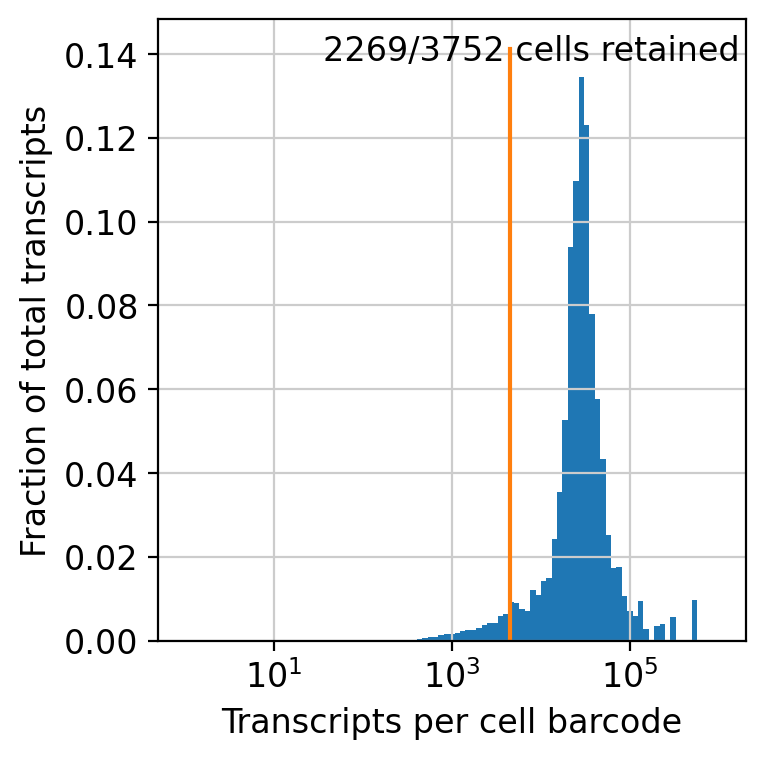

Barcode Filtering  (2269/3752 cells retained)

Anoxia_2hrs_WT_4


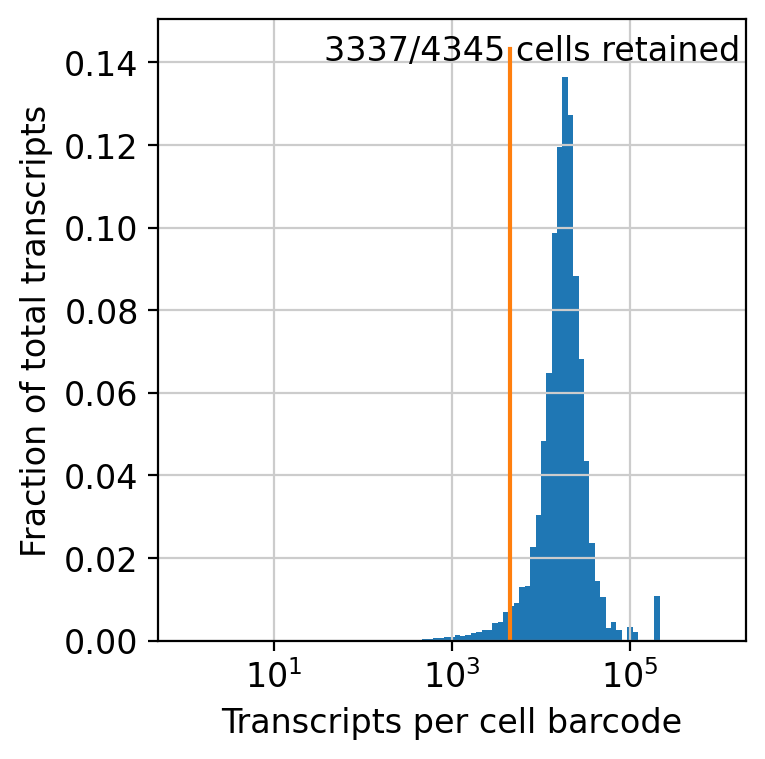

Barcode Filtering  (3337/4345 cells retained)

Normoxia_10hpf_WT_1


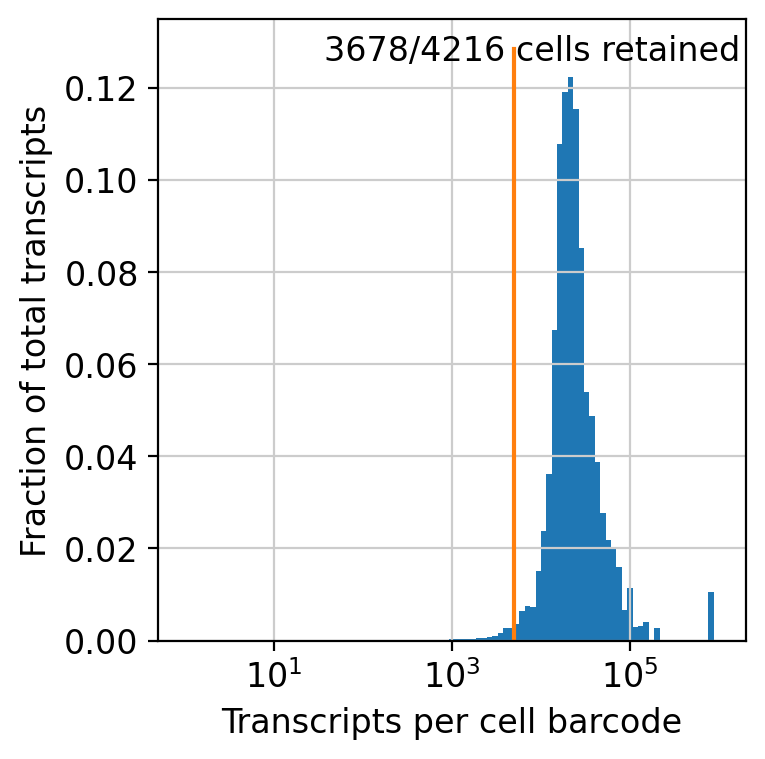

Barcode Filtering  (3678/4216 cells retained)

Normoxia_10hpf_WT_2


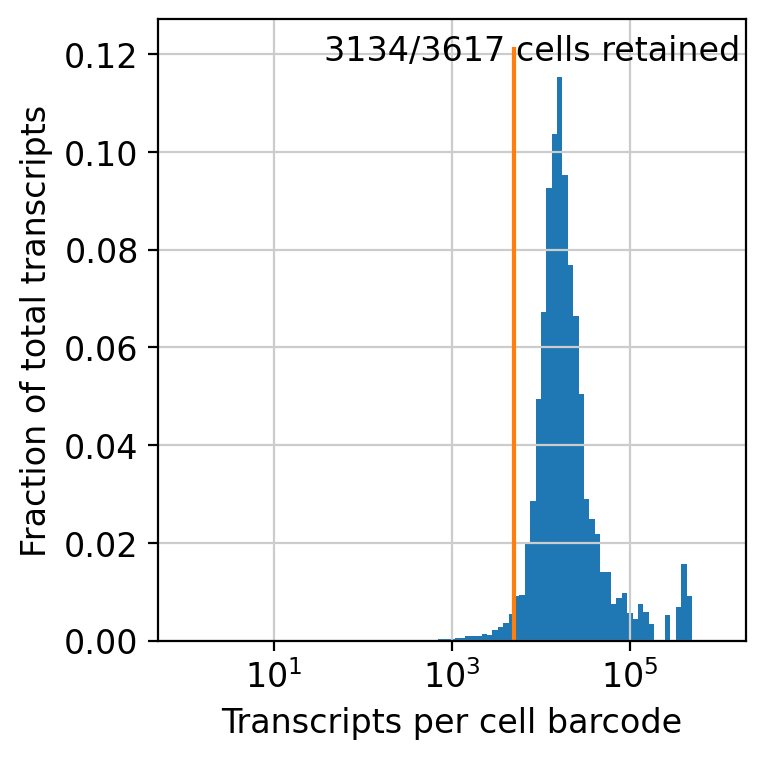

Barcode Filtering  (3134/3617 cells retained)

Normoxia_10hpf_WT_3


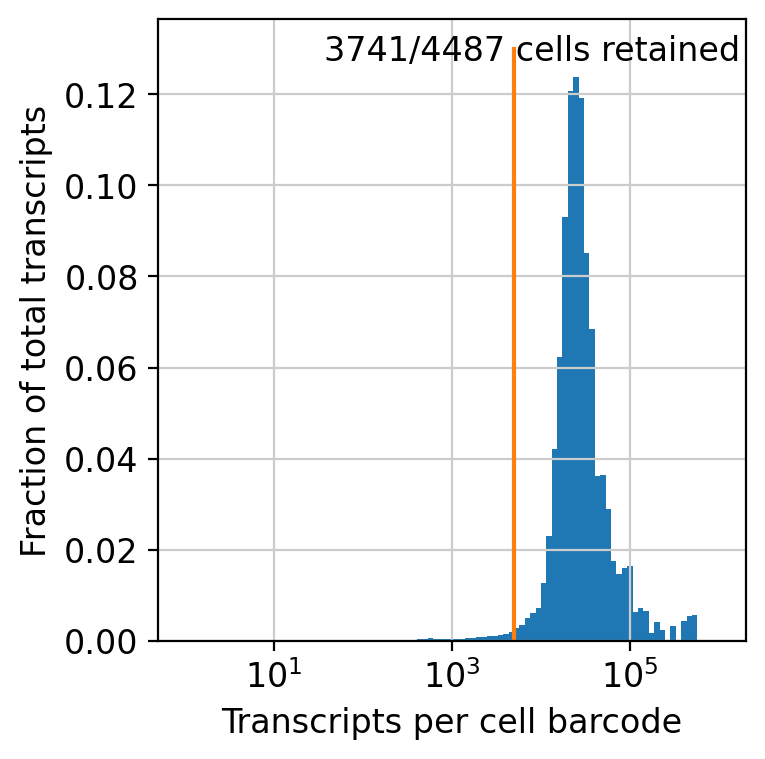

Barcode Filtering  (3741/4487 cells retained)

Normoxia_10hpf_WT_4


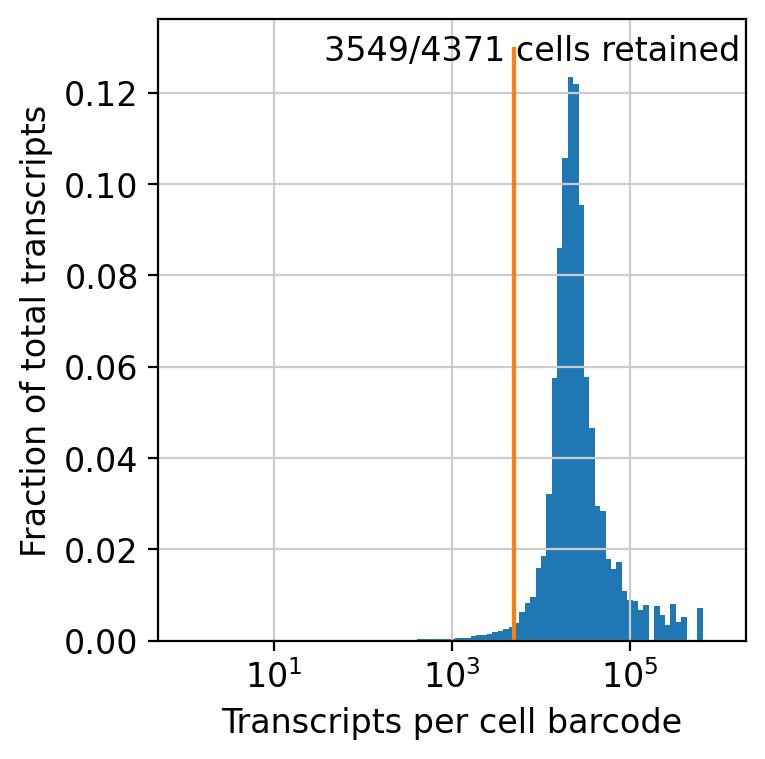

Barcode Filtering  (3549/4371 cells retained)

Normoxia_6hpf_WT_1


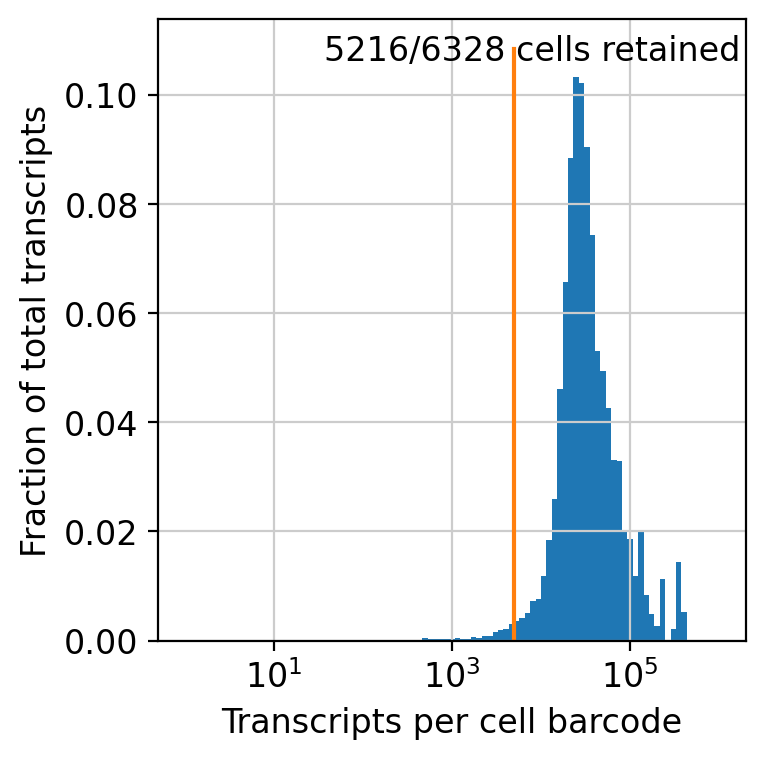

Barcode Filtering  (5216/6328 cells retained)

Normoxia_6hpf_WT_2


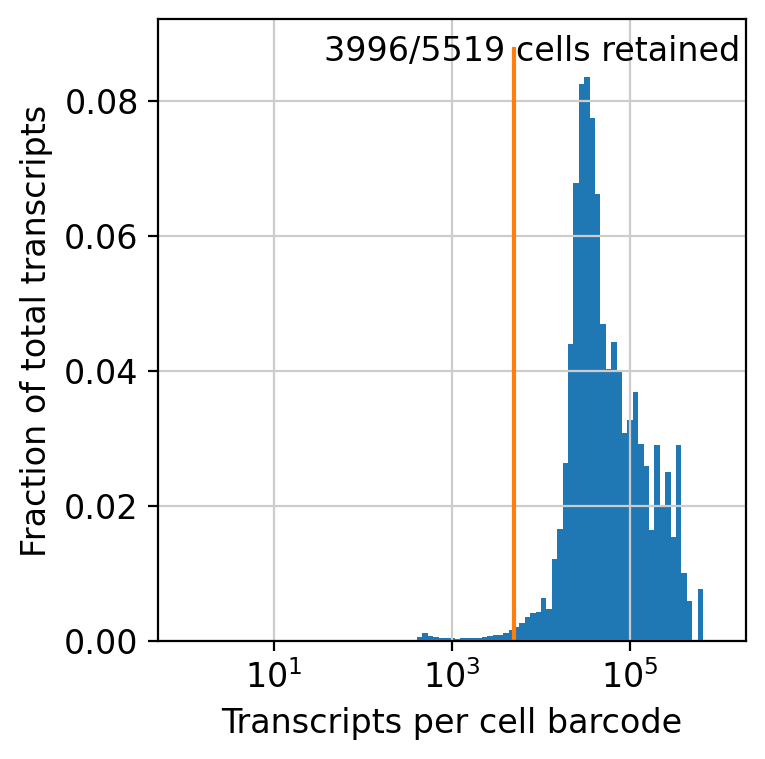

Barcode Filtering  (3996/5519 cells retained)

Normoxia_6hpf_WT_3


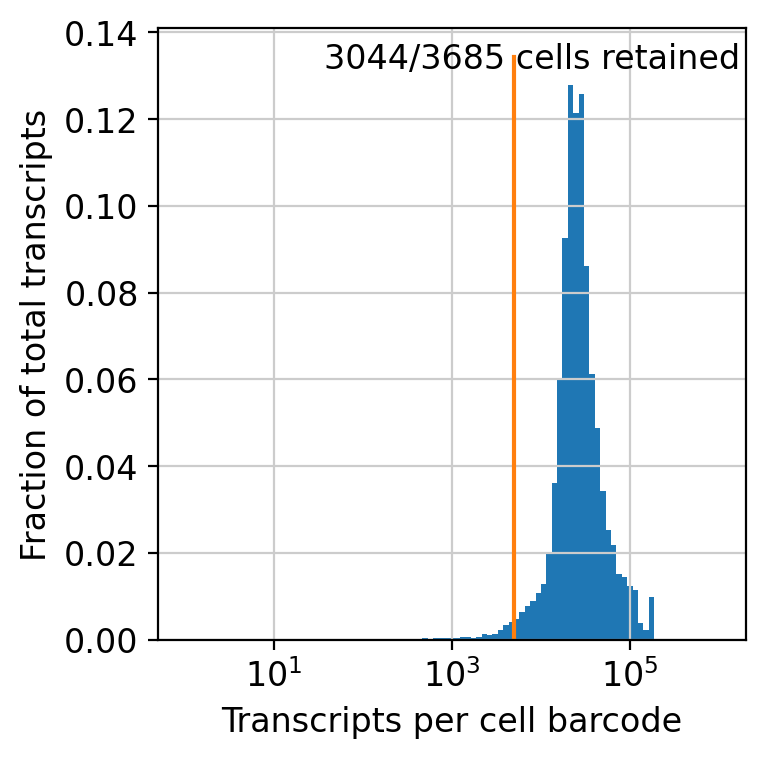

Barcode Filtering  (3044/3685 cells retained)

Normoxia_6hpf_WT_4


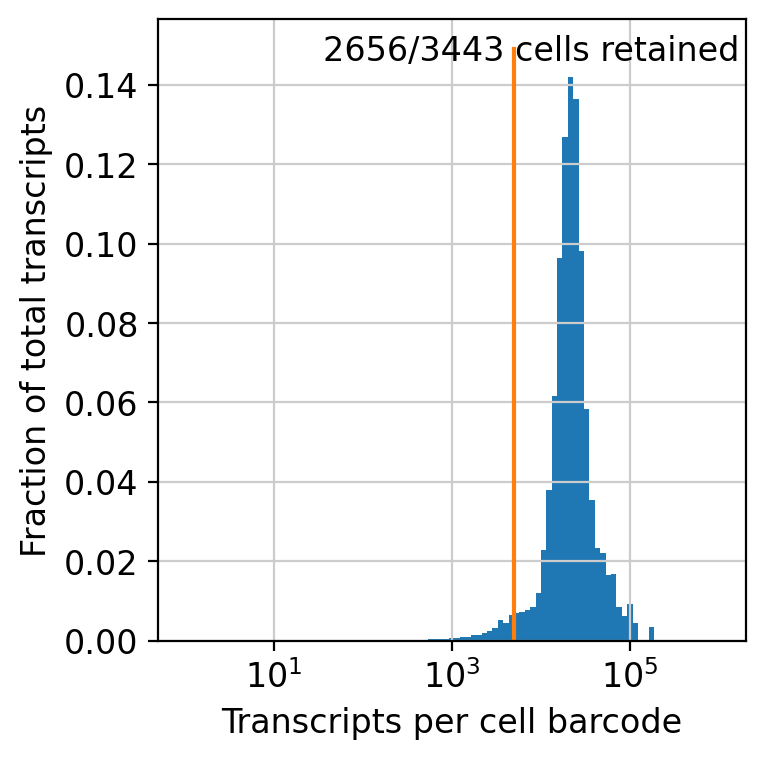

Barcode Filtering  (2656/3443 cells retained)

Normoxia_8hpf_WT_1


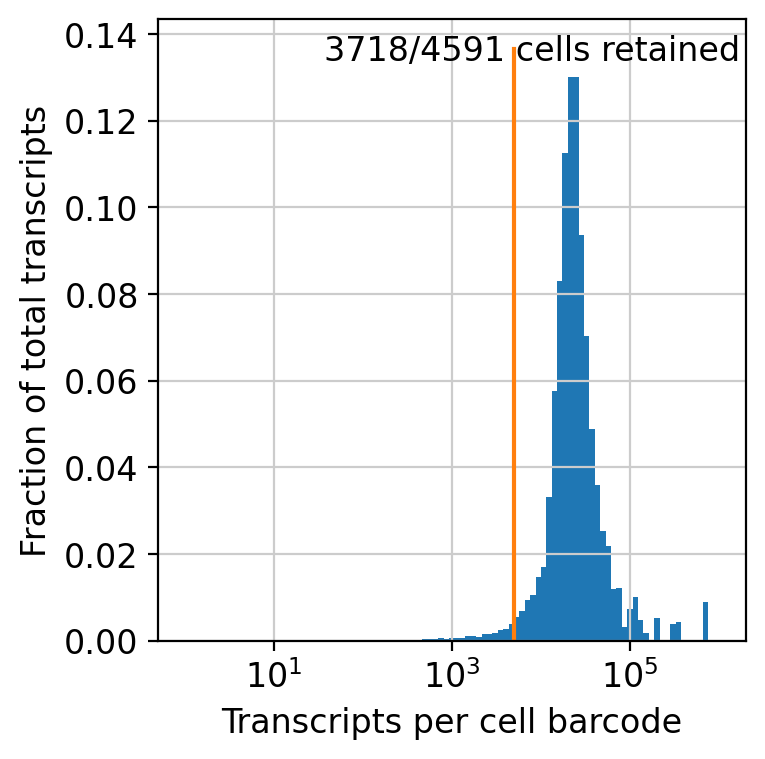

Barcode Filtering  (3718/4591 cells retained)

Normoxia_8hpf_WT_2


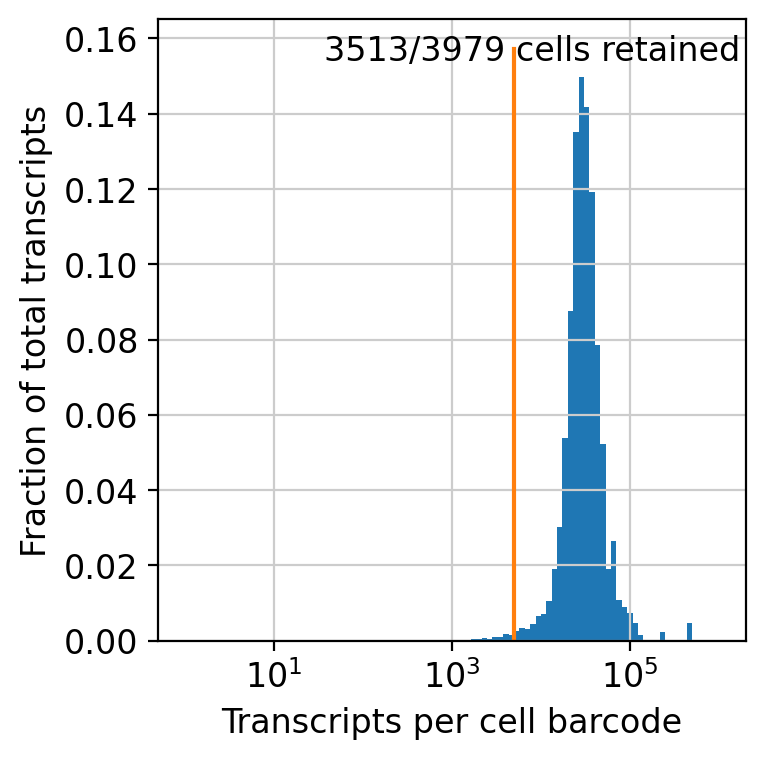

Barcode Filtering  (3513/3979 cells retained)

Normoxia_8hpf_WT_3


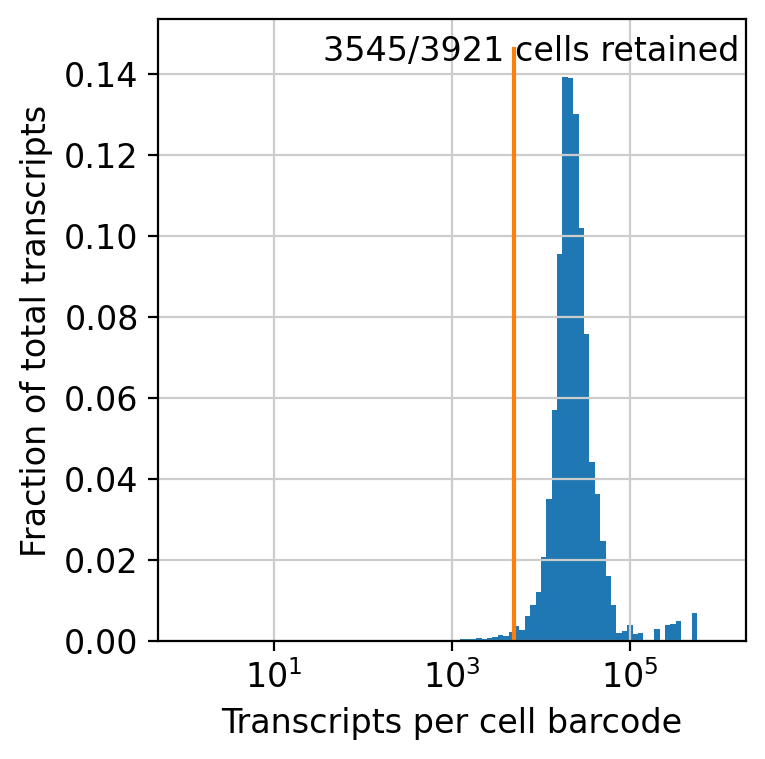

Barcode Filtering  (3545/3921 cells retained)

Normoxia_8hpf_WT_4


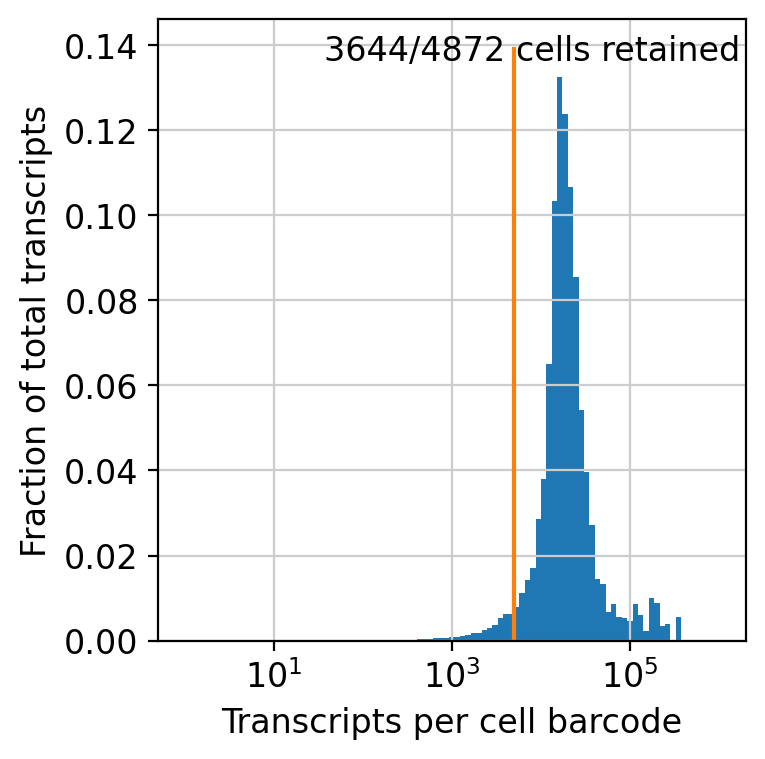

Barcode Filtering  (3644/4872 cells retained)

Reoxy_2hrs_WT_1


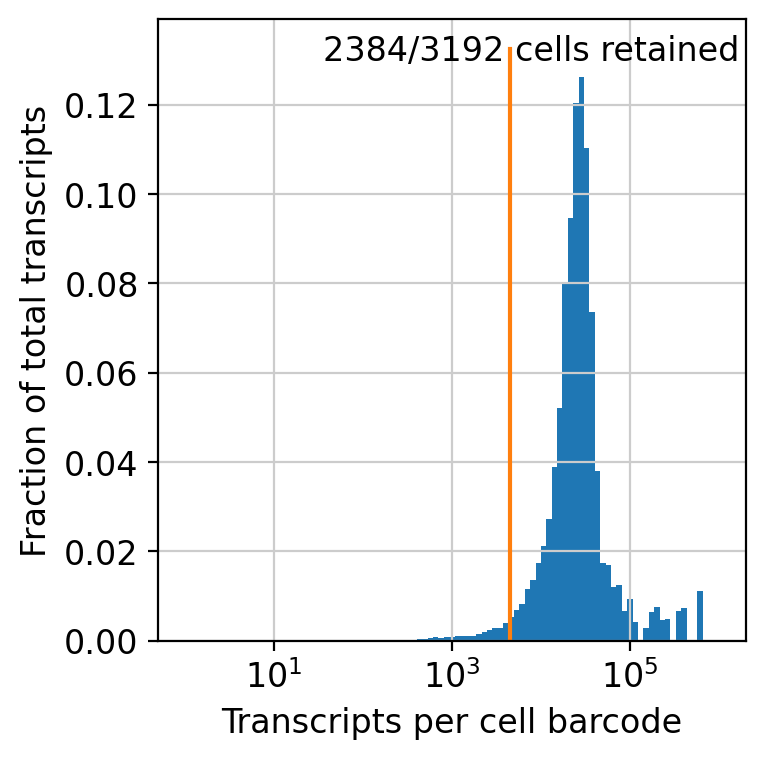

Barcode Filtering  (2384/3192 cells retained)

Reoxy_2hrs_WT_2


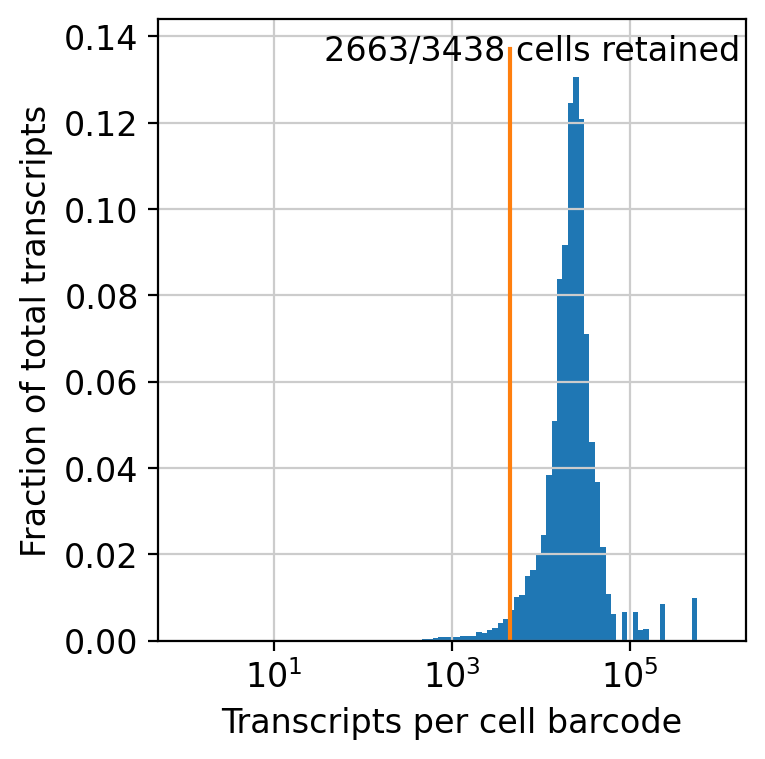

Barcode Filtering  (2663/3438 cells retained)

Reoxy_2hrs_WT_3


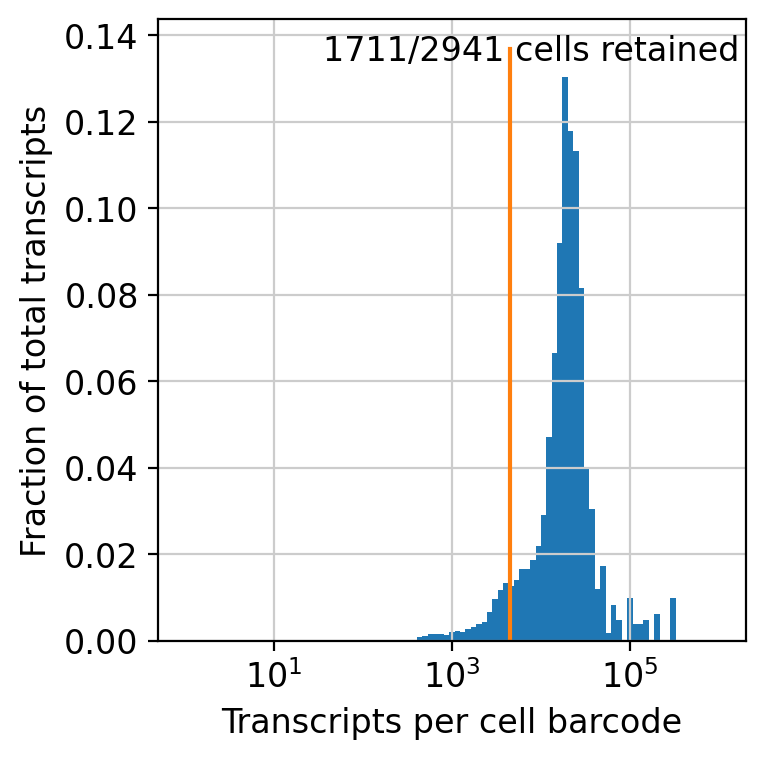

Barcode Filtering  (1711/2941 cells retained)

Reoxy_2hrs_WT_4


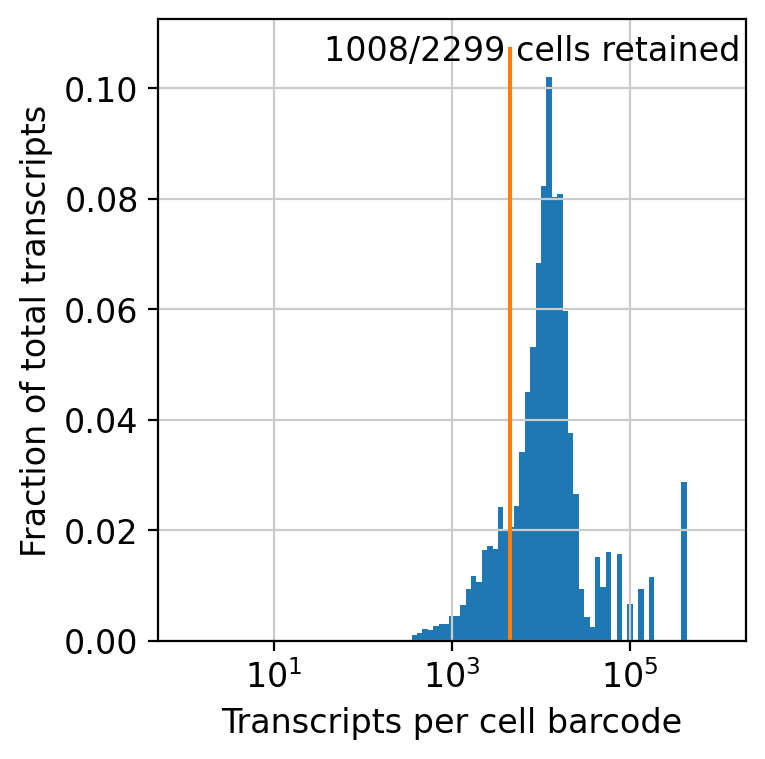

Barcode Filtering  (1008/2299 cells retained)



In [ ]:
ab_filter_flag = True # run with this as False to identify thresholds, then switch to True to actually filter cells

for n, sample in enumerate(Samples):
  print(sample)
  dew.filter_abundant_barcodes(adata_dict[sample], filter_cells=ab_filter_flag, threshold=adata_dict[sample].uns['counts_thresh'])


### Perform Mitochondrial Filtering

Anoxia_2hrs_WT_1


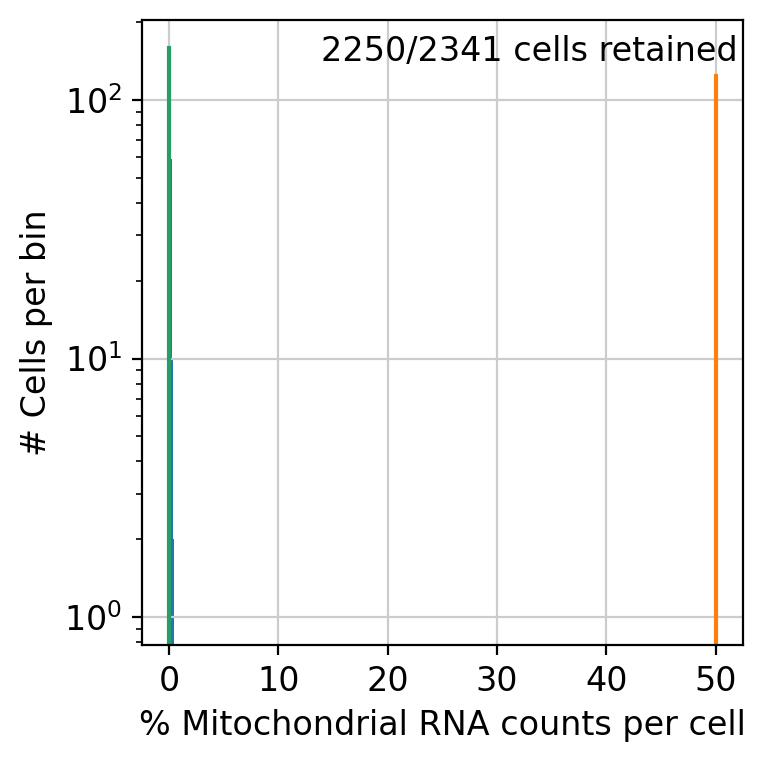

Mito-Filtering  (2250/2341 cells retained)

Anoxia_2hrs_WT_2


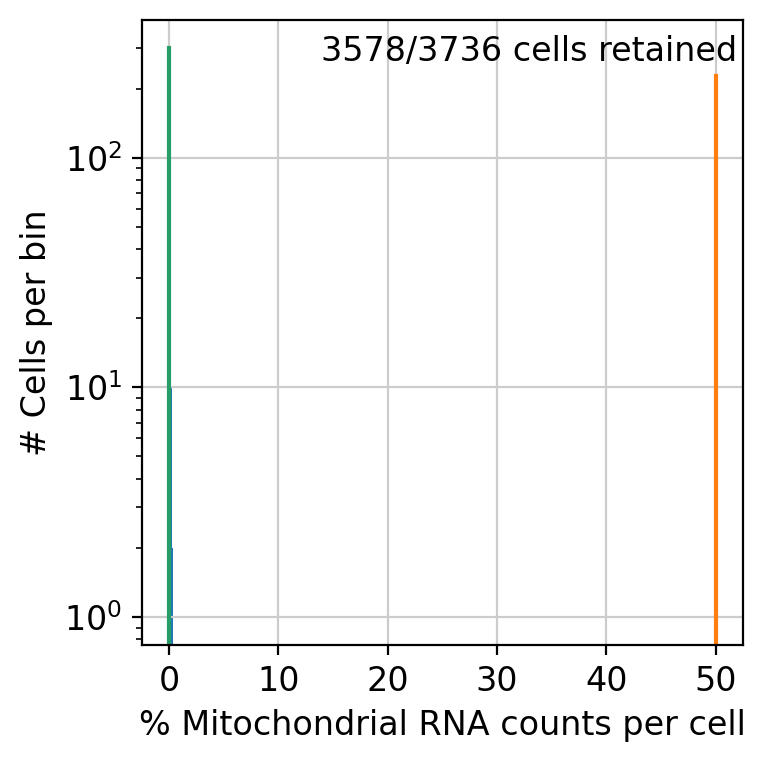

Mito-Filtering  (3578/3736 cells retained)

Anoxia_2hrs_WT_3


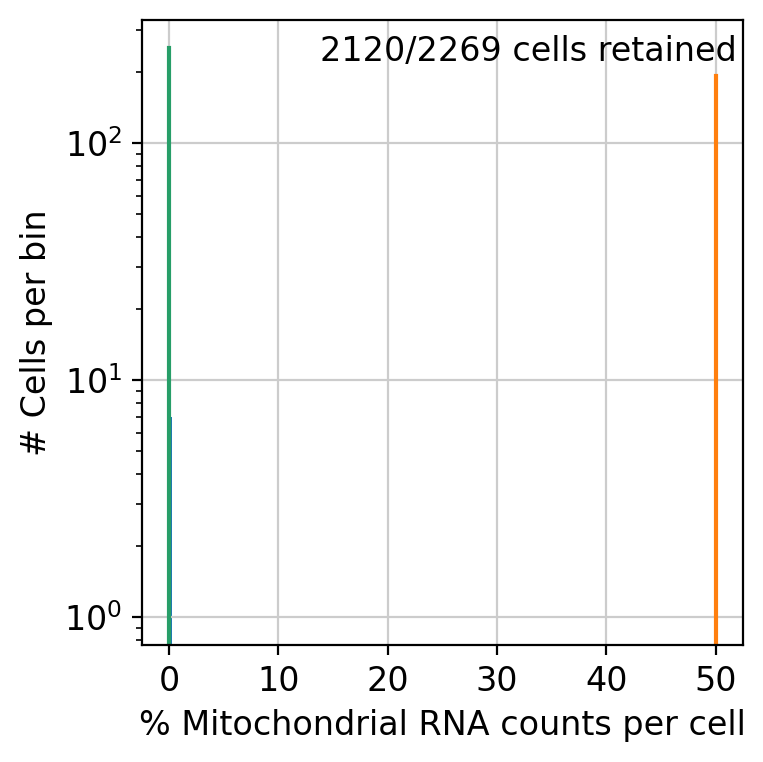

Mito-Filtering  (2120/2269 cells retained)

Anoxia_2hrs_WT_4


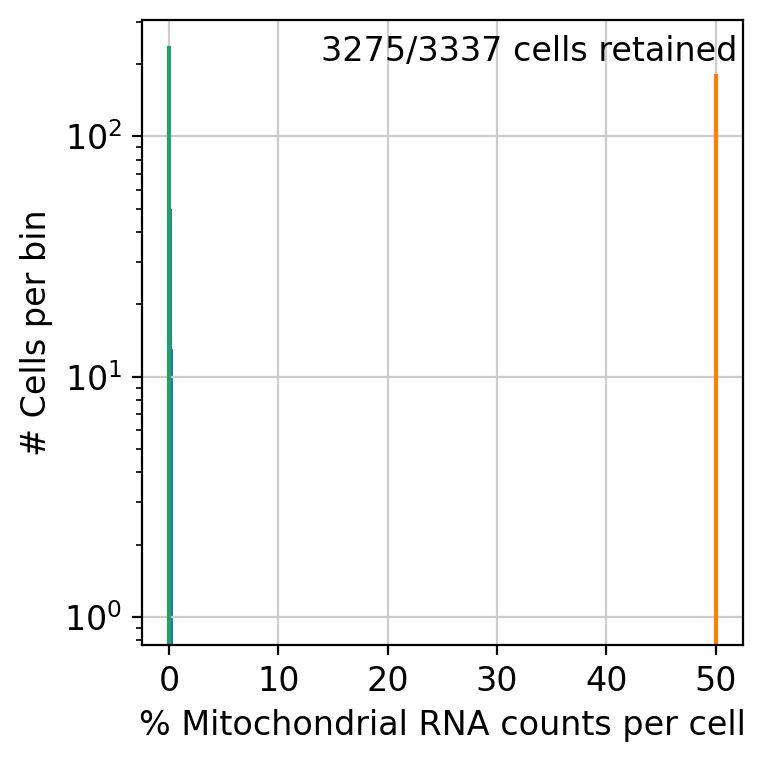

Mito-Filtering  (3275/3337 cells retained)

Normoxia_10hpf_WT_1


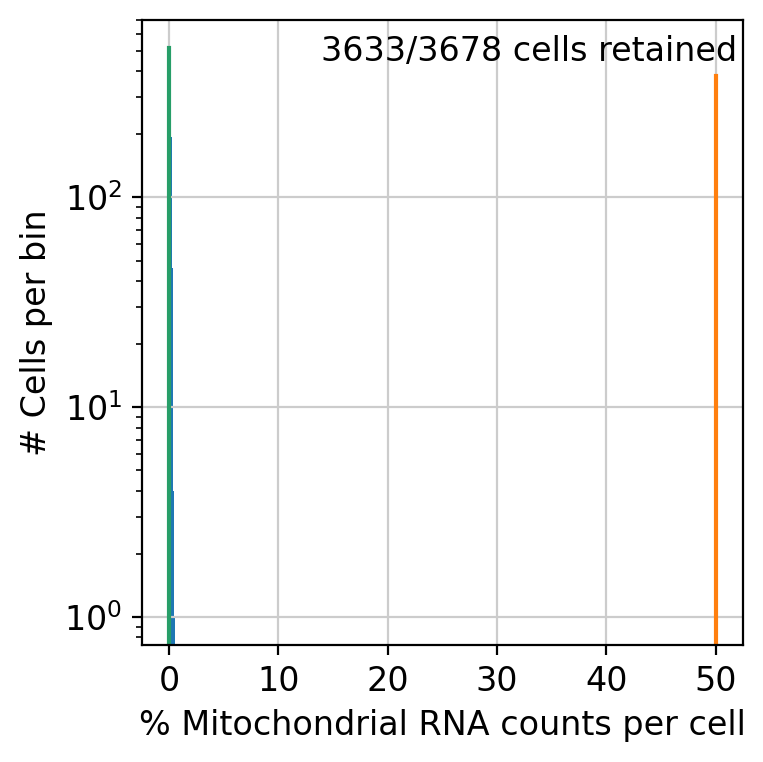

Mito-Filtering  (3633/3678 cells retained)

Normoxia_10hpf_WT_2


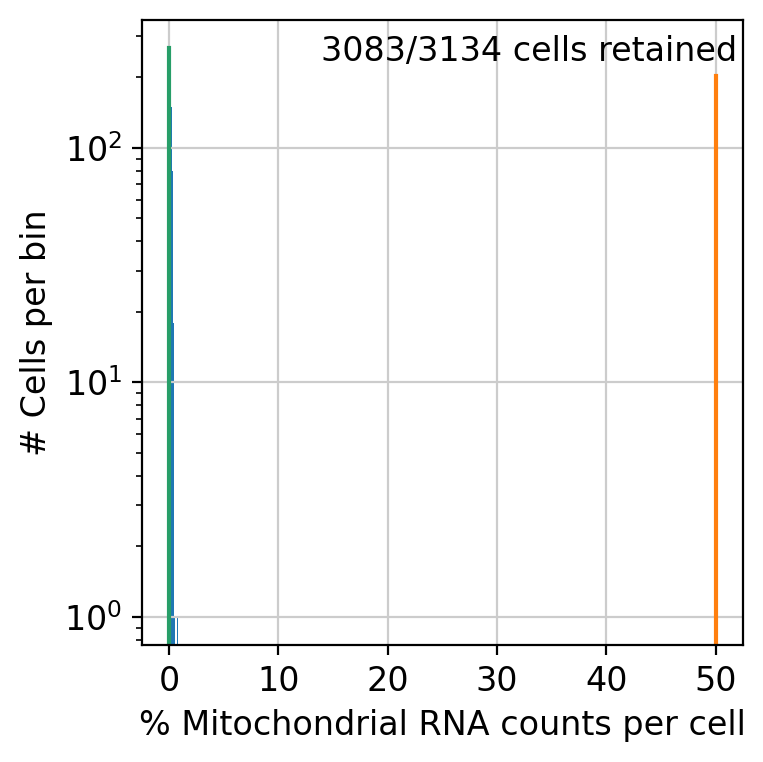

Mito-Filtering  (3083/3134 cells retained)

Normoxia_10hpf_WT_3


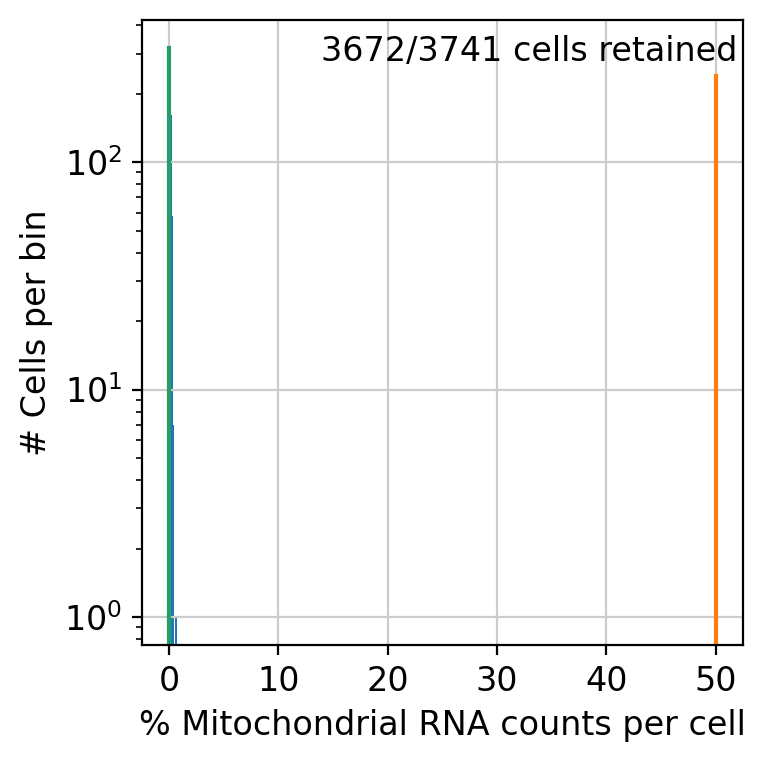

Mito-Filtering  (3672/3741 cells retained)

Normoxia_10hpf_WT_4


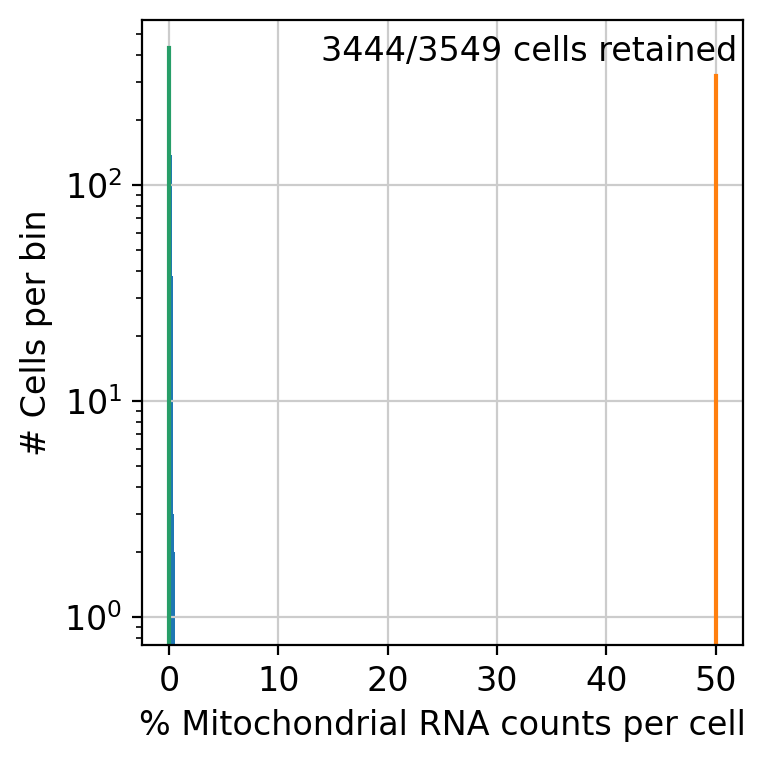

Mito-Filtering  (3444/3549 cells retained)

Normoxia_6hpf_WT_1


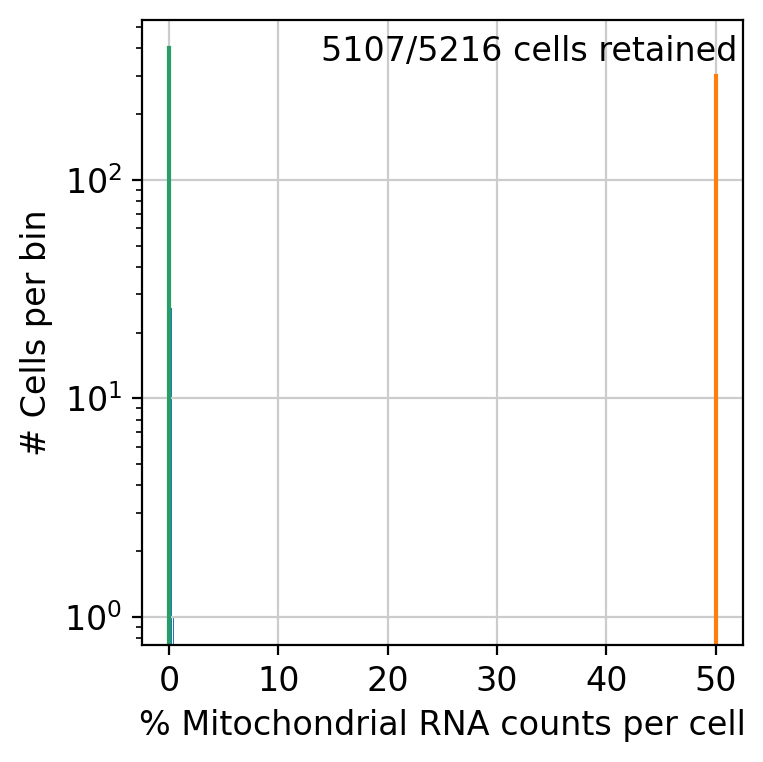

Mito-Filtering  (5107/5216 cells retained)

Normoxia_6hpf_WT_2


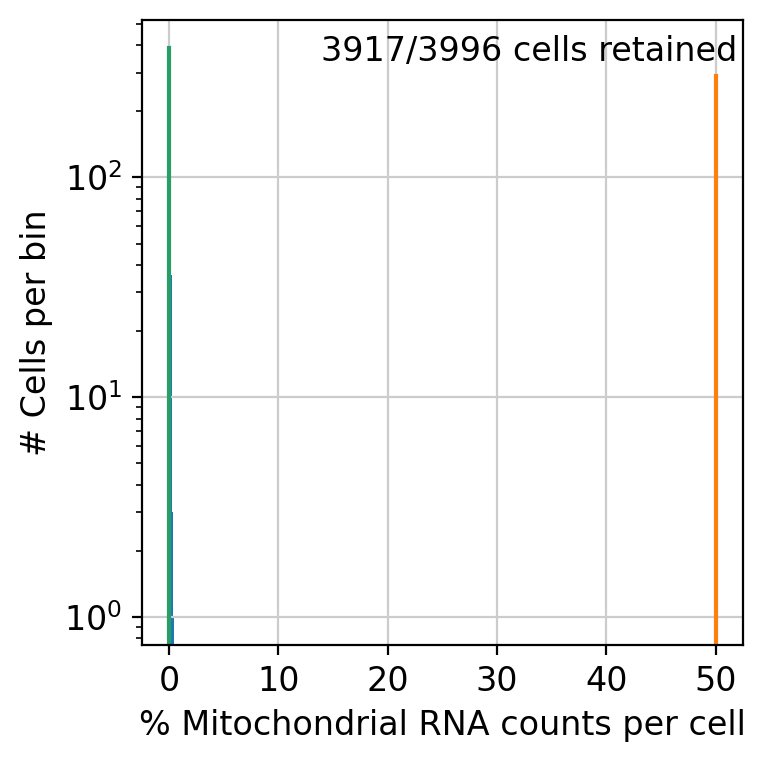

Mito-Filtering  (3917/3996 cells retained)

Normoxia_6hpf_WT_3


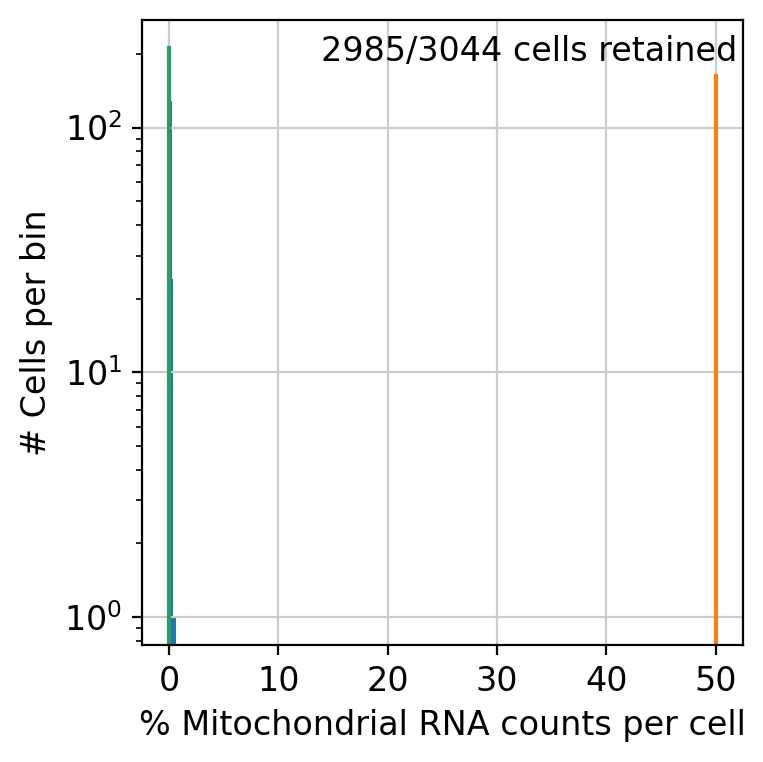

Mito-Filtering  (2985/3044 cells retained)

Normoxia_6hpf_WT_4


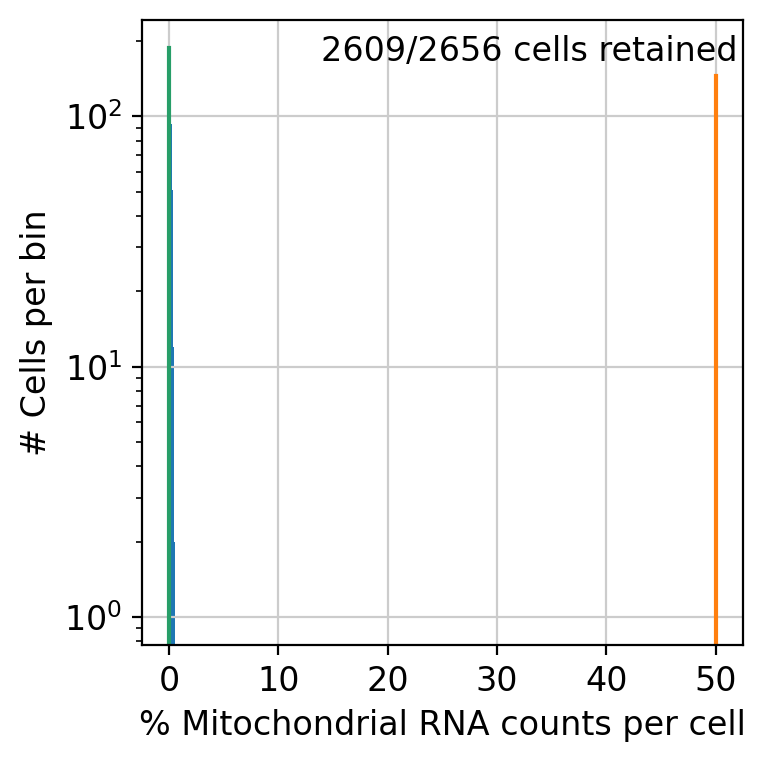

Mito-Filtering  (2609/2656 cells retained)

Normoxia_8hpf_WT_1


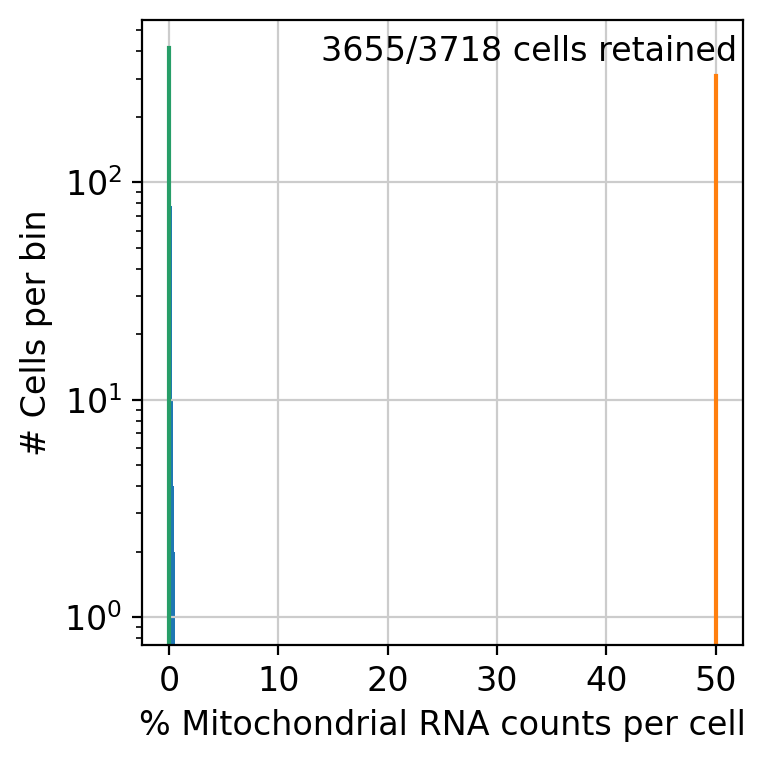

Mito-Filtering  (3655/3718 cells retained)

Normoxia_8hpf_WT_2


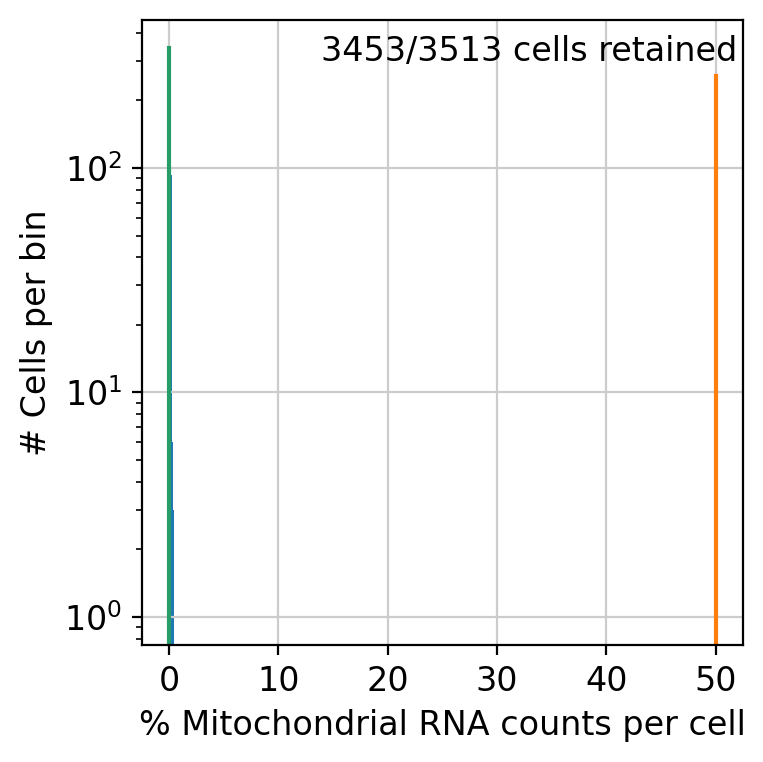

Mito-Filtering  (3453/3513 cells retained)

Normoxia_8hpf_WT_3


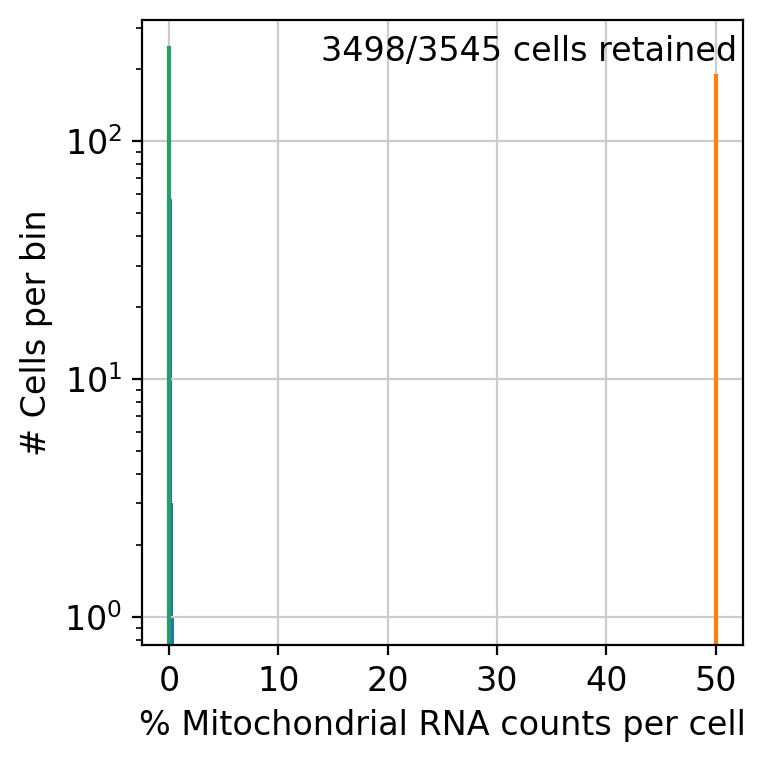

Mito-Filtering  (3498/3545 cells retained)

Normoxia_8hpf_WT_4


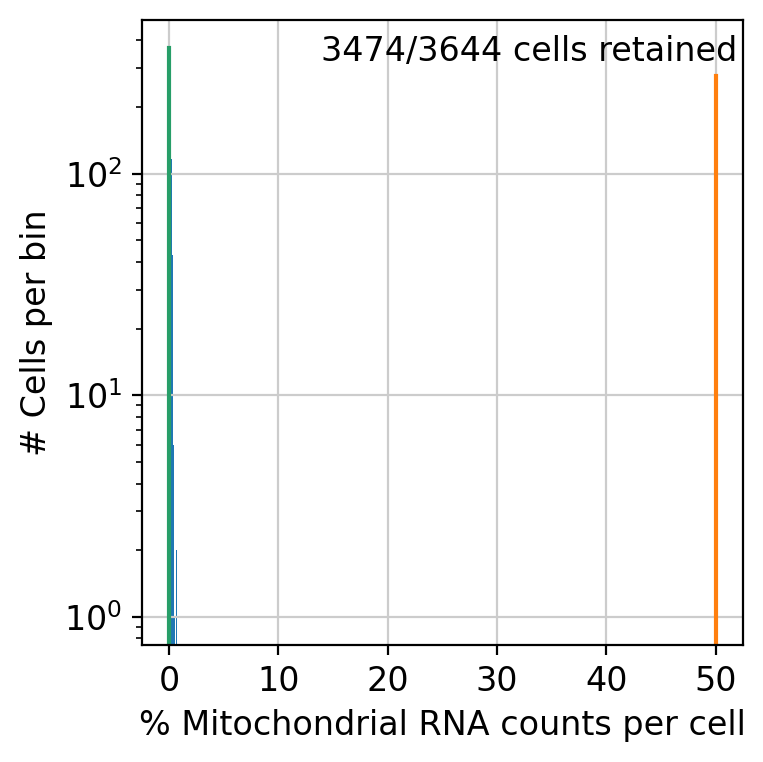

Mito-Filtering  (3474/3644 cells retained)

Reoxy_2hrs_WT_1


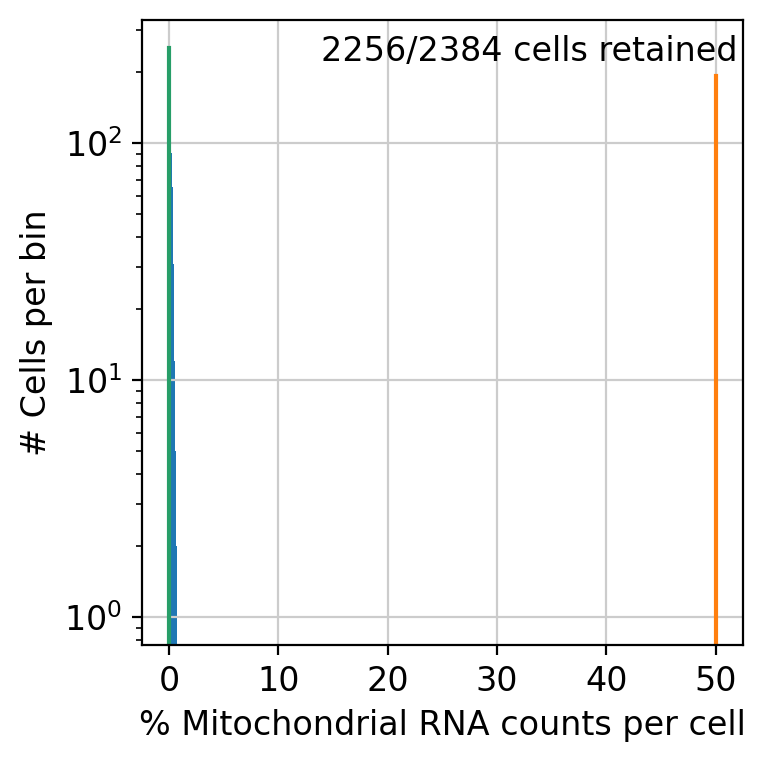

Mito-Filtering  (2256/2384 cells retained)

Reoxy_2hrs_WT_2


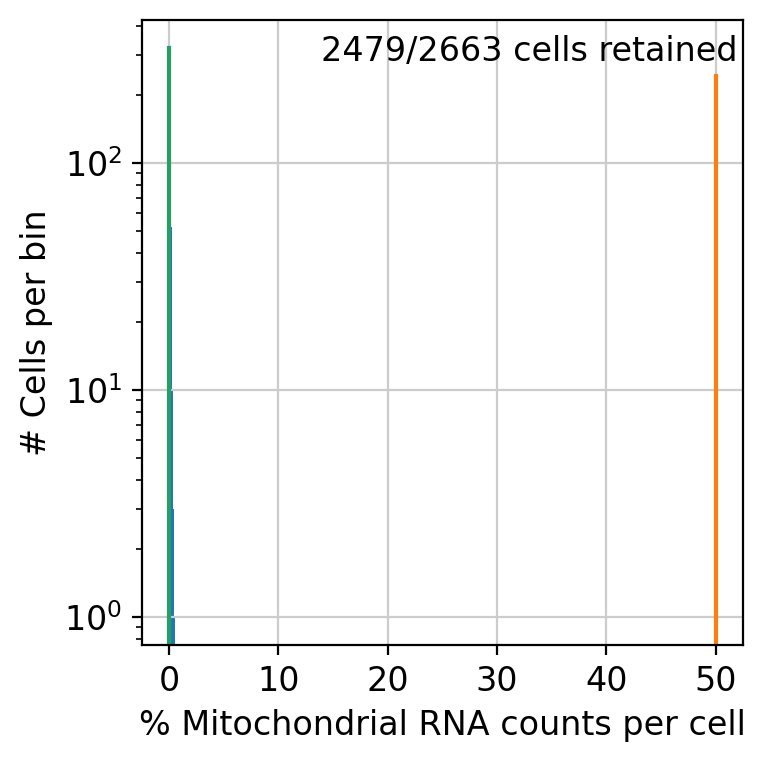

Mito-Filtering  (2479/2663 cells retained)

Reoxy_2hrs_WT_3


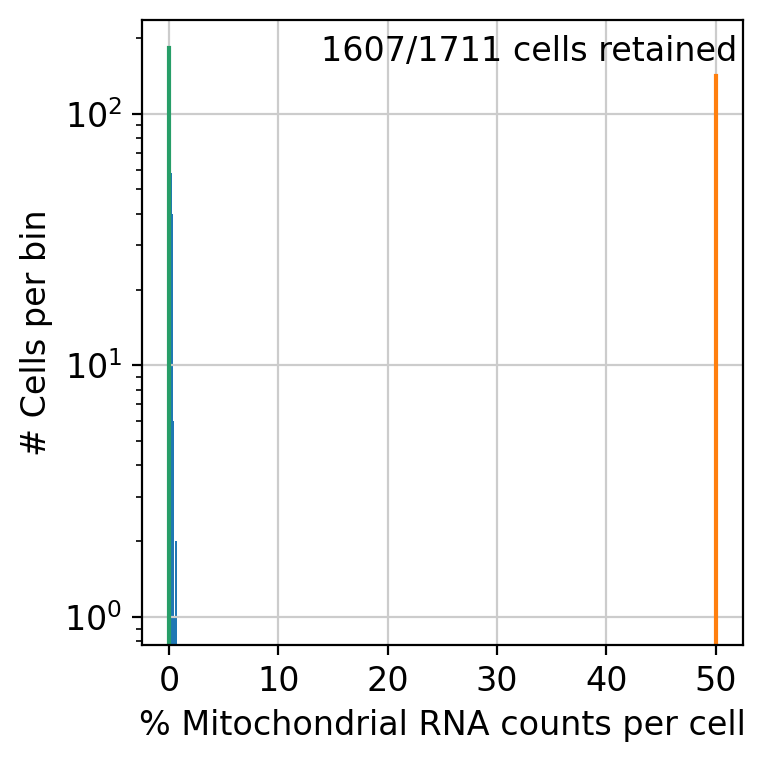

Mito-Filtering  (1607/1711 cells retained)

Reoxy_2hrs_WT_4


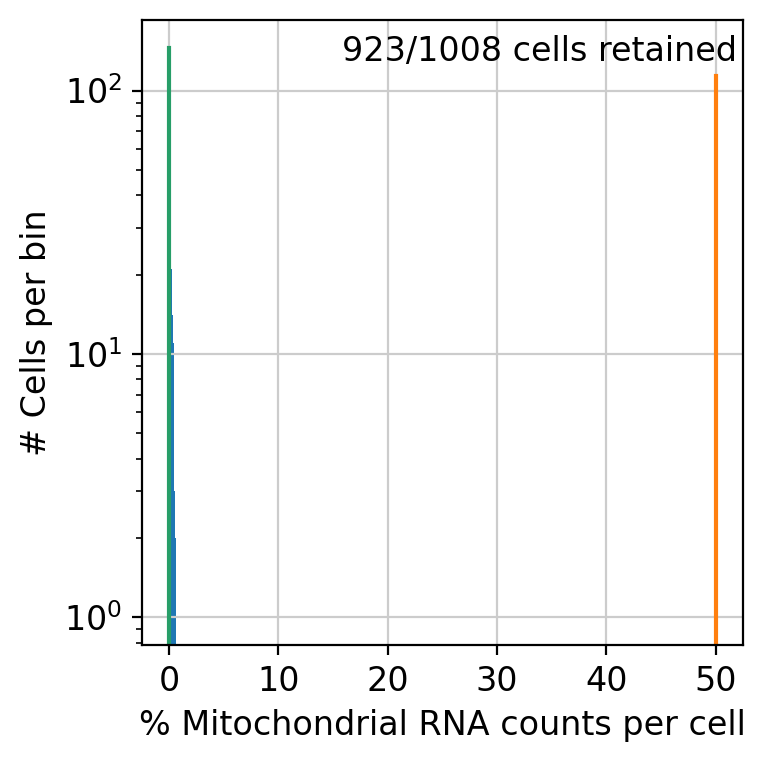

Mito-Filtering  (923/1008 cells retained)



In [ ]:
mito_upper_threshold = 50 # only acceptable for this dataset, see below
mito_filter_flag = True  # run with this as False to identify thresholds, then switch to True to actually filter cells

for n, sample in enumerate(Samples):
  print(sample)
  adata_dict[sample] = dew.filter_mito(adata_dict[sample], filter_cells=mito_filter_flag, upper_threshold=mito_upper_threshold)

### Perform Cell Doublet Filtering

Anoxia_2hrs_WT_1


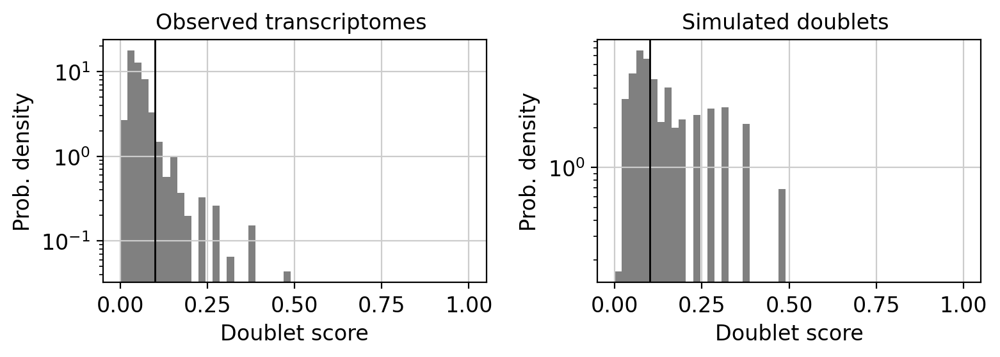

Doublet Filtering  (2002/2250 cells retained)

Anoxia_2hrs_WT_2


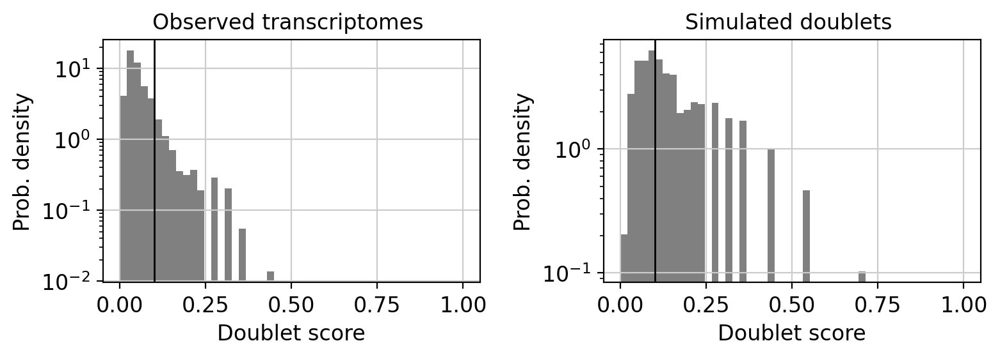

Doublet Filtering  (3176/3578 cells retained)

Anoxia_2hrs_WT_3


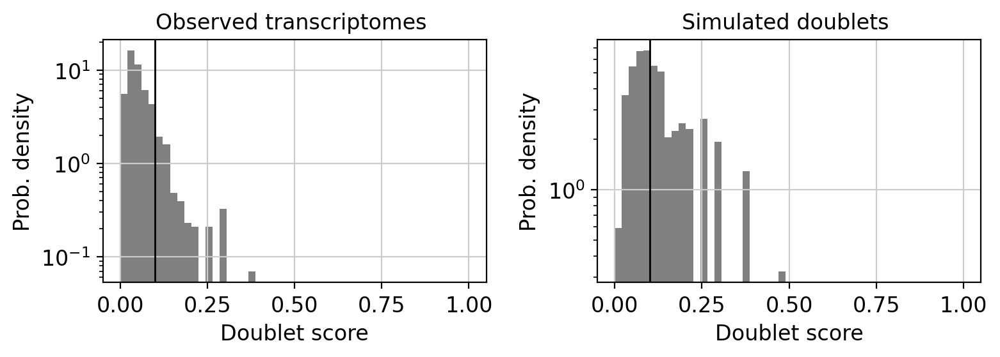

Doublet Filtering  (1884/2120 cells retained)

Anoxia_2hrs_WT_4


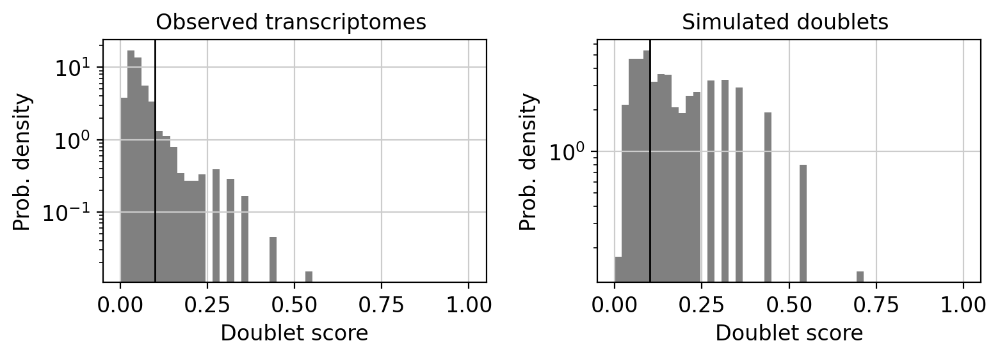

Doublet Filtering  (2865/3275 cells retained)

Normoxia_10hpf_WT_1


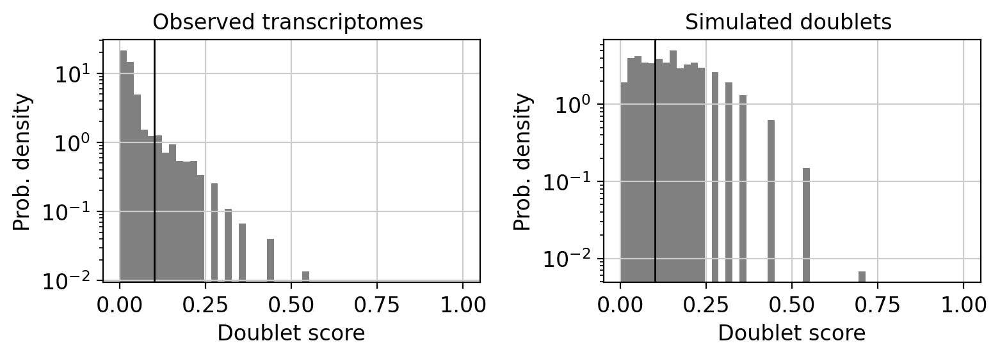

Doublet Filtering  (3237/3633 cells retained)

Normoxia_10hpf_WT_2


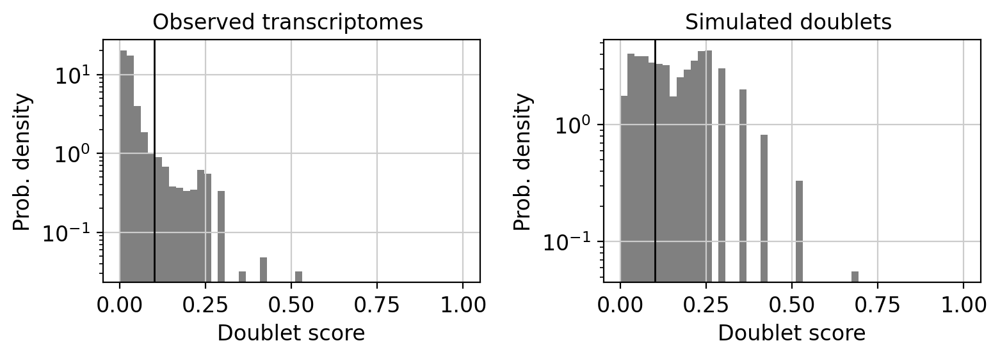

Doublet Filtering  (2792/3083 cells retained)

Normoxia_10hpf_WT_3


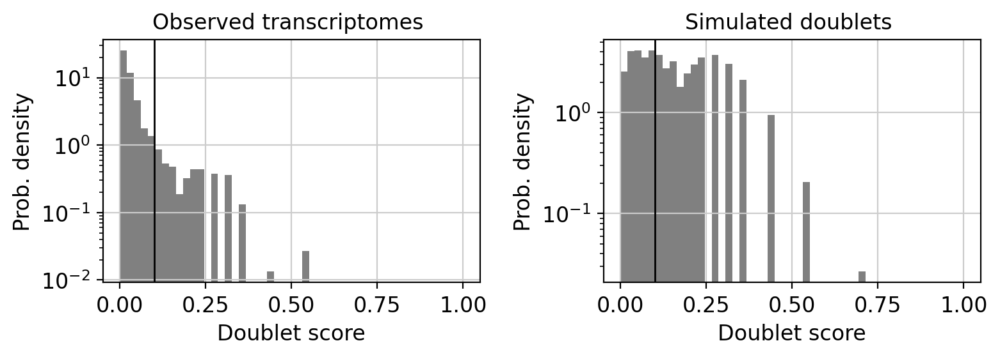

Doublet Filtering  (3360/3672 cells retained)

Normoxia_10hpf_WT_4


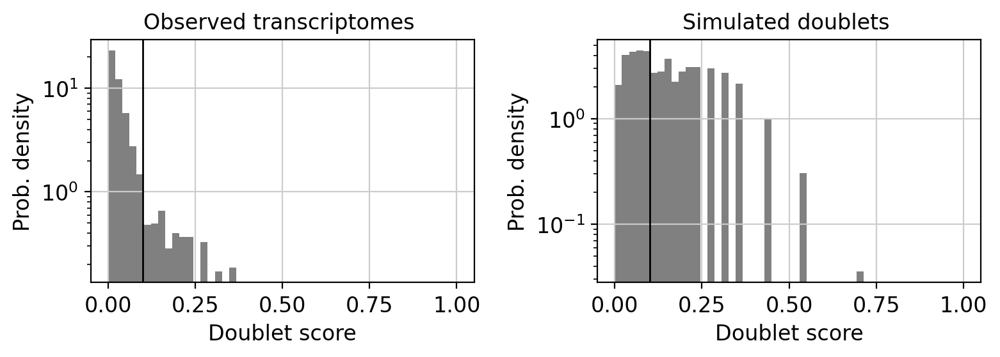

Doublet Filtering  (3154/3444 cells retained)

Normoxia_6hpf_WT_1


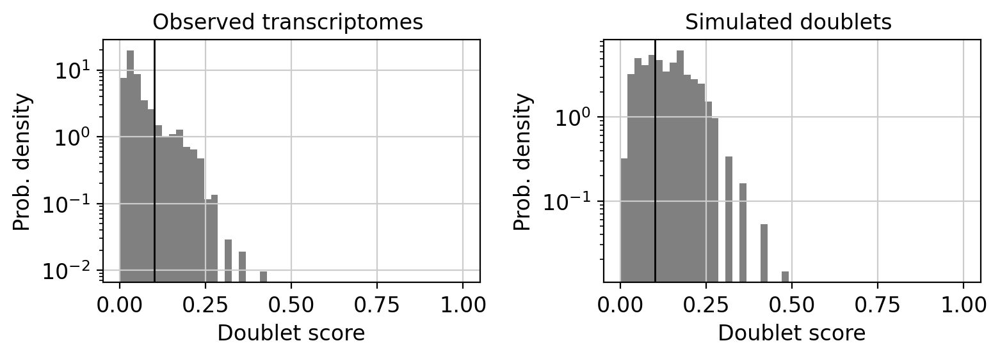

Doublet Filtering  (4319/5107 cells retained)

Normoxia_6hpf_WT_2


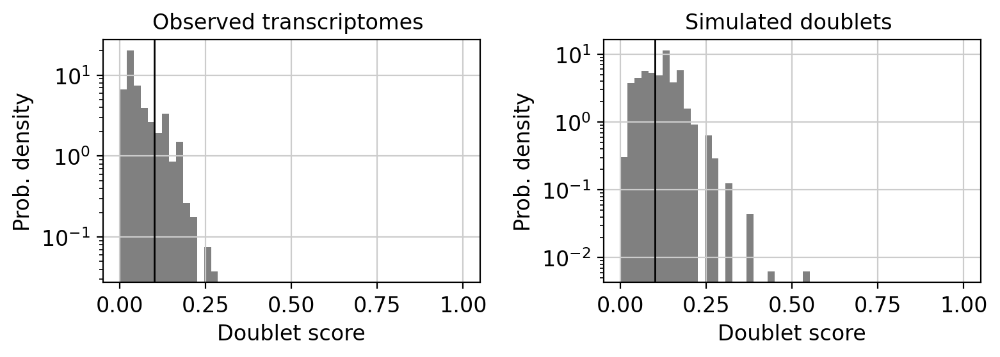

Doublet Filtering  (3208/3917 cells retained)

Normoxia_6hpf_WT_3


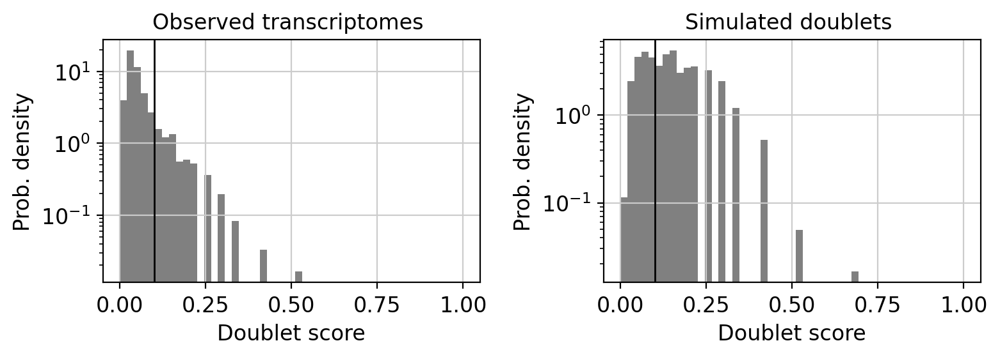

Doublet Filtering  (2589/2985 cells retained)

Normoxia_6hpf_WT_4


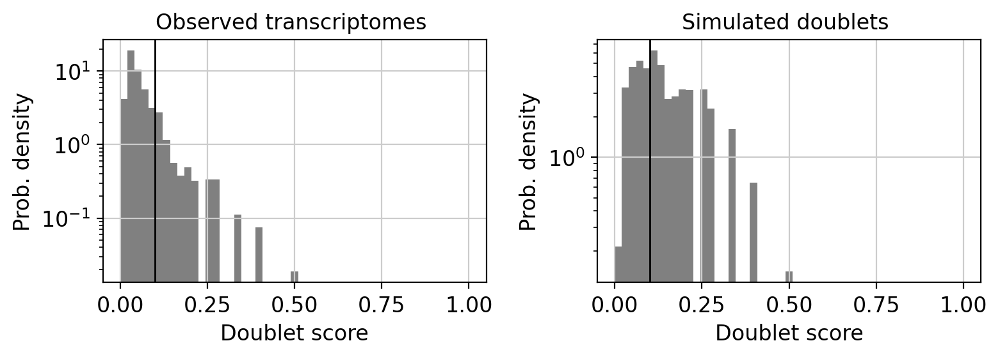

Doublet Filtering  (2262/2609 cells retained)

Normoxia_8hpf_WT_1


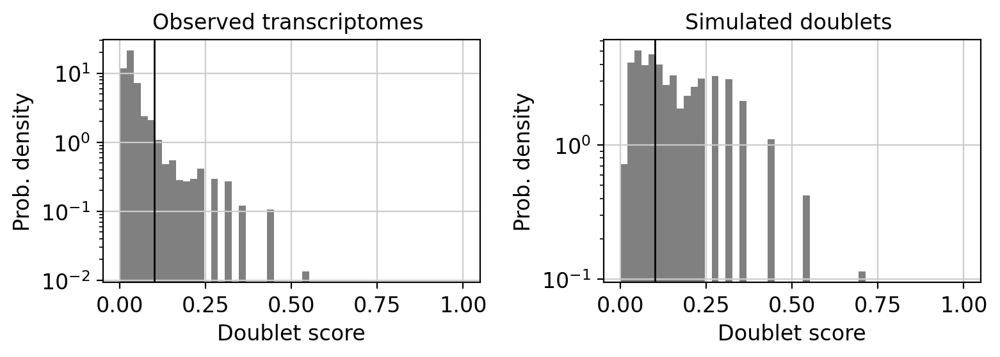

Doublet Filtering  (3343/3655 cells retained)

Normoxia_8hpf_WT_2


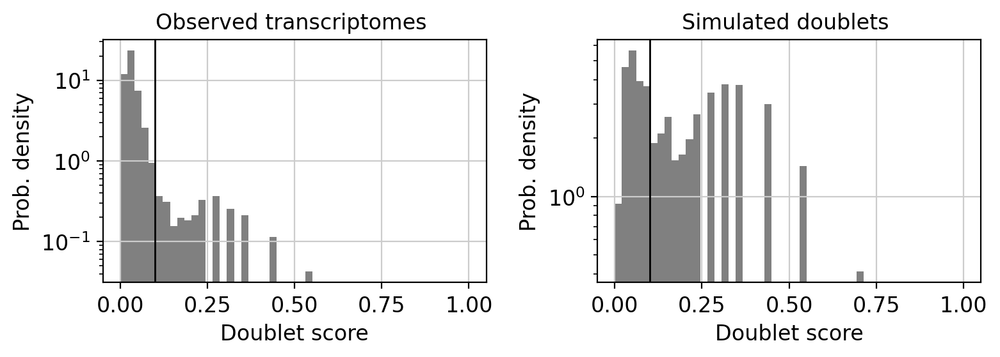

Doublet Filtering  (3241/3453 cells retained)

Normoxia_8hpf_WT_3


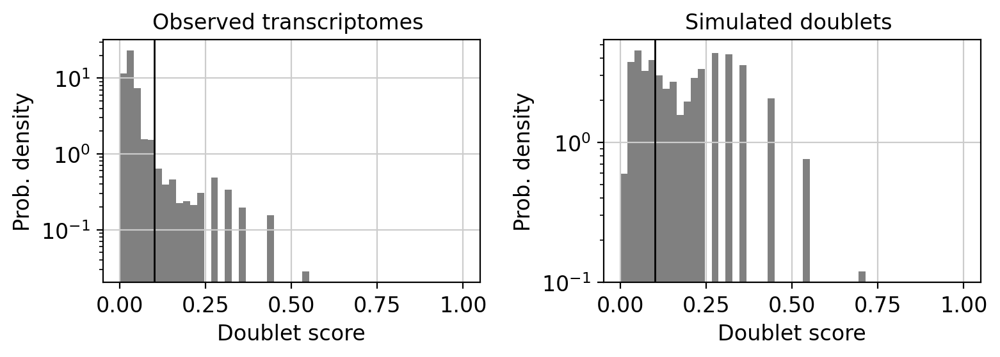

Doublet Filtering  (3235/3498 cells retained)

Normoxia_8hpf_WT_4


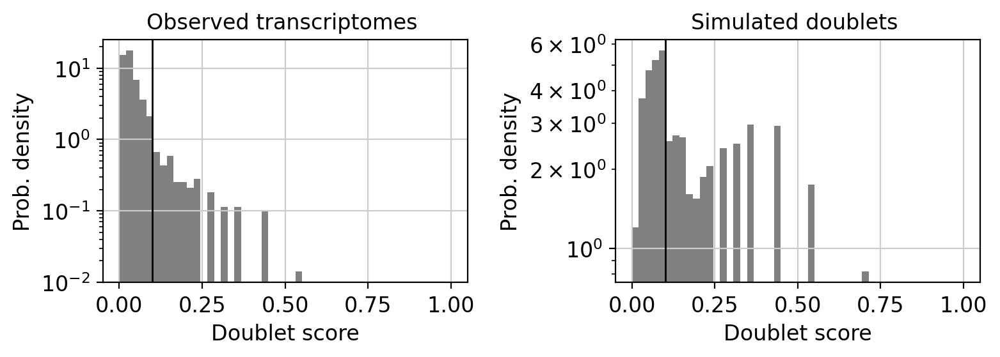

Doublet Filtering  (3216/3474 cells retained)

Reoxy_2hrs_WT_1


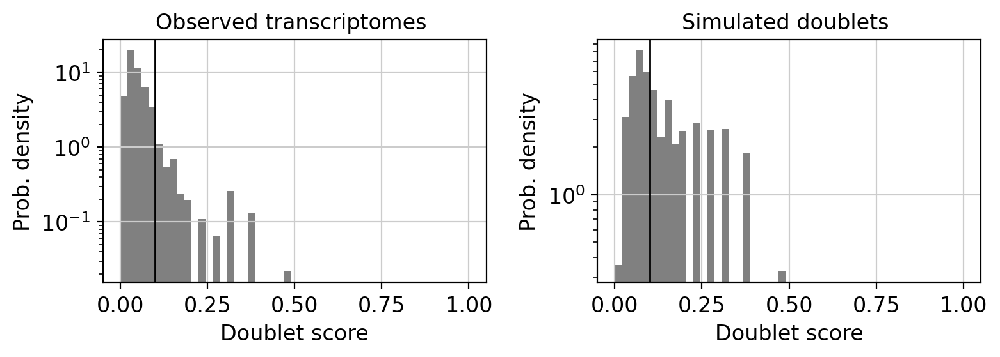

Doublet Filtering  (2055/2256 cells retained)

Reoxy_2hrs_WT_2


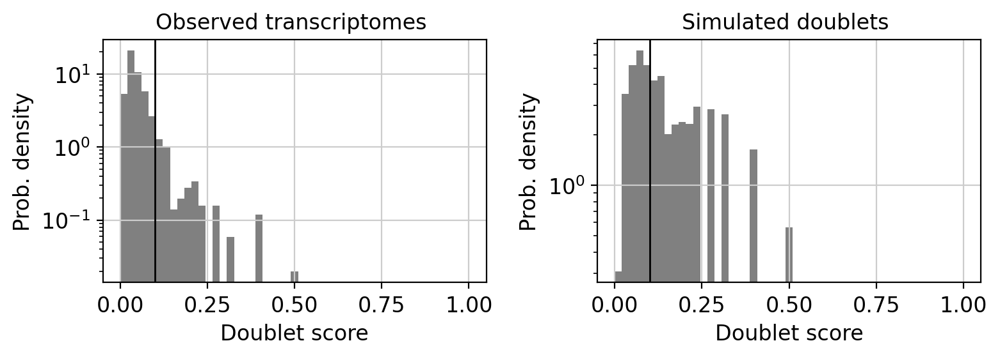

Doublet Filtering  (2289/2479 cells retained)

Reoxy_2hrs_WT_3


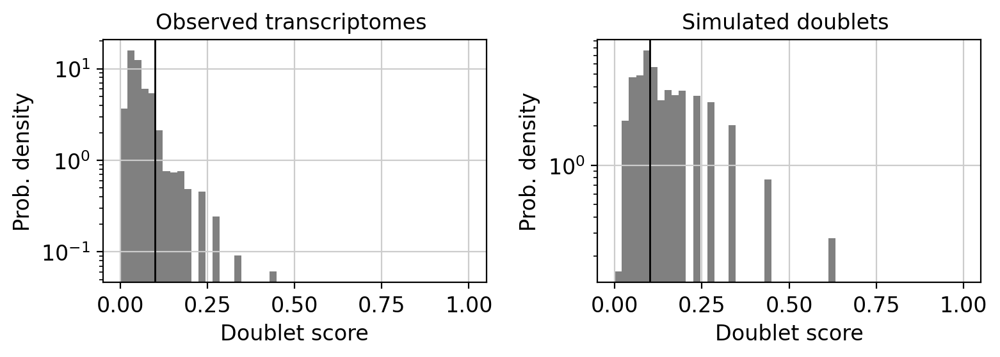

Doublet Filtering  (1419/1607 cells retained)

Reoxy_2hrs_WT_4


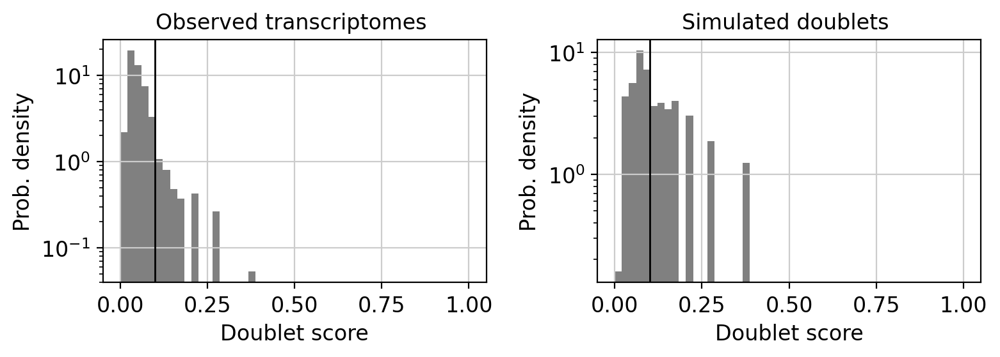

Doublet Filtering  (858/923 cells retained)



In [ ]:
scrub_threshold = 0.1
scrub_filter_flag = True  # run with this as False to identify thresholds, then switch to True to actually filter cells

for n, sample in enumerate(Samples):
  print(sample)
  adata_dict[sample] = dew.filter_scrublet(adata_dict[sample], threshold=scrub_threshold, filter_cells=scrub_filter_flag)

## Merge Libraries


In [ ]:
if 'adata' in globals(): del adata
adata = adata_dict['Anoxia_2hrs_WT_1'].concatenate(
    adata_dict['Anoxia_2hrs_WT_2'],
    adata_dict['Anoxia_2hrs_WT_3'],
    adata_dict['Anoxia_2hrs_WT_4'],
    adata_dict['Normoxia_10hpf_WT_1'],
    adata_dict['Normoxia_10hpf_WT_2'],
    adata_dict['Normoxia_10hpf_WT_3'],
    adata_dict['Normoxia_10hpf_WT_4'],
    adata_dict['Normoxia_6hpf_WT_1'],
    adata_dict['Normoxia_6hpf_WT_2'],
    adata_dict['Normoxia_6hpf_WT_3'],
    adata_dict['Normoxia_6hpf_WT_4'],
    adata_dict['Normoxia_8hpf_WT_1'],
    adata_dict['Normoxia_8hpf_WT_2'],
    adata_dict['Normoxia_8hpf_WT_3'],
    adata_dict['Normoxia_8hpf_WT_4'],
    adata_dict['Reoxy_2hrs_WT_1'],
    adata_dict['Reoxy_2hrs_WT_2'],
    adata_dict['Reoxy_2hrs_WT_3'],
    adata_dict['Reoxy_2hrs_WT_4']
)

print('\n', adata)


 AnnData object with n_obs × n_vars = 54504 × 31655
    obs: 'sample', 'species', 'gene_count', 'tscp_count', 'mread_count', 'bc1_wind', 'bc2_wind', 'bc3_wind', 'bc1_well', 'bc2_well', 'bc3_well', 'n_genes', 'Group', 'Condition', 'total_counts', 'n_genes_by_counts', 'n_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'doublet_score', 'predicted_doublet', 'batch'
    var: 'gene_id', 'genome', 'n_cells', 'mito', 'ribo', 'n_cells_by_counts-0', 'mean_counts-0', 'log1p_mean_counts-0', 'pct_dropout_by_counts-0', 'total_counts-0', 'log1p_total_counts-0', 'n_cells_by_counts-1', 'mean_counts-1', 'log1p_mean_counts-1', 'pct_dropout_by_counts-1', 'total_counts-1', 'log1p_total_counts-1', 'n_cells_by_counts-10', 'mean_counts-10', 'log1

In [ ]:
# mitochondrial genes
adata.var['mt'] = adata.var_names.str.startswith(('mt-','MT-'))
# ribosomal genes
adata.var['ribo'] = adata.var_names.str.startswith(('mt-','MT-'))

In [ ]:
adata.var

,gene_id,genome,n_cells,mito,ribo,n_cells_by_counts-0,mean_counts-0,log1p_mean_counts-0,pct_dropout_by_counts-0,total_counts-0,...,pct_dropout_by_counts-8,total_counts-8,log1p_total_counts-8,n_cells_by_counts-9,mean_counts-9,log1p_mean_counts-9,pct_dropout_by_counts-9,total_counts-9,log1p_total_counts-9,mt
a1cf,LL0000000001,GRCZ11Law,4458,False,False,197,0.554891,0.441405,91.584793,1299.0,...,94.210123,1768.0,7.478170,308,0.503754,0.407964,92.292292,2013.0,7.607878,False
a2ml,LL0000000002,GRCZ11Law,3419,False,False,128,0.187100,0.171513,94.532251,438.0,...,94.612730,2217.0,7.704361,298,0.542042,0.433108,92.542543,2166.0,7.681099,False
aaas,LL0000000003,GRCZ11Law,7930,False,False,161,0.078172,0.075267,93.122597,183.0,...,92.772239,432.0,6.070738,493,0.147147,0.137278,87.662663,588.0,6.378426,False
aacs,LL0000000004,GRCZ11Law,14740,False,False,260,0.147373,0.137475,88.893635,345.0,...,78.565951,1748.0,7.466799,1175,0.519770,0.418559,70.595596,2077.0,7.639161,False
aadac,LL0000000005,GRCZ11Law,560,False,False,29,0.014097,0.013998,98.761213,33.0,...,99.252301,40.0,3.713572,85,0.023023,0.022762,97.872873,92.0,4.532599,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
echdc1,LL0000040552,GRCZ11Law,678,False,False,7,0.002990,0.002986,99.700982,7.0,...,99.060583,52.0,3.970292,78,0.019770,0.019577,98.048048,79.0,4.382027,False
sipa1l2-1,LL0000040553,GRCZ11Law,2631,False,False,92,0.042717,0.041830,96.070056,100.0,...,95.552147,250.0,5.525453,284,0.084835,0.081428,92.892893,339.0,5.828946,False
eme2,LL0000040556,GRCZ11Law,301,False,False,7,0.003845,0.003837,99.700982,9.0,...,99.654908,18.0,2.944439,29,0.007758,0.007728,99.274274,31.0,3.465736,False
si:ch211-122l14.5,LL0000040557,GRCZ11Law,6,False,False,1,0.000427,0.000427,99.957283,1.0,...,100.000000,0.0,0.000000,0,0.000000,0.000000,100.000000,0.0,0.000000,False


In [ ]:
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt','ribo'], percent_top=None, log1p=False, inplace=True)

In [ ]:
mito_genes = adata.var_names.str.startswith('mt-')
# for each cell compute fraction of counts in mito genes vs. all genes
# the `.A1` is only necessary as X is sparse (to transform to a dense array after summing)
adata.obs['percent_mt2'] = np.sum(
    adata[:, mito_genes].X, axis=1).A1 / np.sum(adata.X, axis=1).A1
# add the total counts per cell as observations-annotation to adata
adata.obs['n_counts'] = adata.X.sum(axis=1).A1

In [ ]:
sc.set_figure_params(dpi=120, figsize=[20,4], fontsize=7)

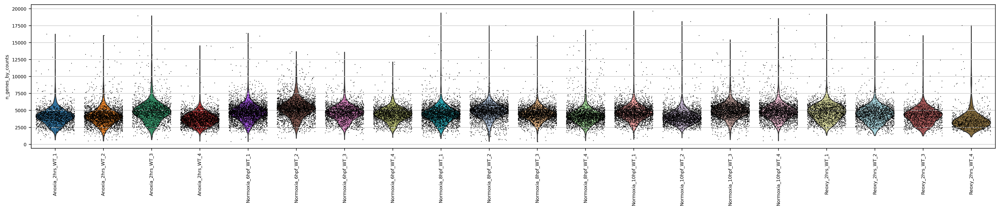

In [ ]:
sc.pl.violin(adata, ['n_genes_by_counts'], jitter=0.4, groupby = 'sample', rotation = 90)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

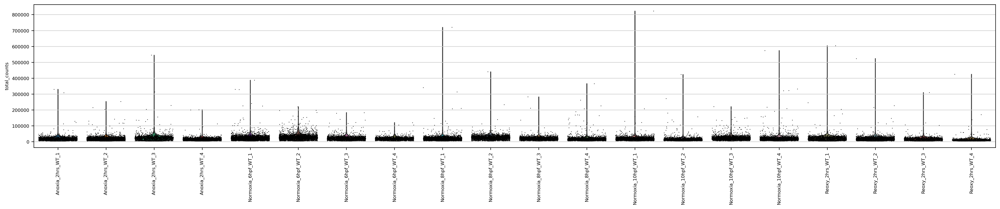

In [ ]:
sc.pl.violin(adata, ['total_counts'], jitter=0.4, groupby = 'sample', rotation = 90)


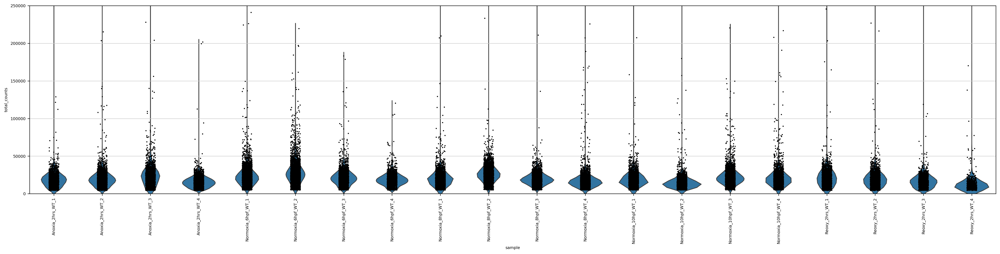

In [ ]:
# Convert the necessary data to a pandas DataFrame
df = pd.DataFrame({
    'total_counts': adata.obs['total_counts'],   # assuming 'total_counts' is in adata.obs
    'sample': adata.obs['sample']                # assuming 'sample' is in adata.obs
})

# Create the violin plot
plt.figure(figsize=(30, 6))  # Adjust the figure size if necessary
sns.violinplot(x='sample', y='total_counts', data=df, inner=None)  # Remove inner lines to make stripplot clearer

# Overlay a strip plot with jitter
sns.stripplot(x='sample', y='total_counts', data=df, jitter=True, color='black', size=2)

# Set y-axis limit
plt.ylim(0, 250000)  # Adjust the limits (0 to 3500) as needed

# Rotate x-axis labels for better visibility
plt.xticks(rotation=90)

# Show the plot
plt.show()

In [ ]:
sc.set_figure_params(dpi=120, figsize=[20,4], fontsize=7)

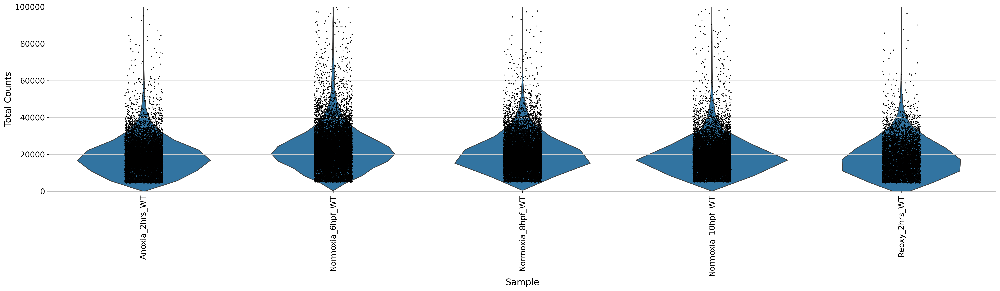

In [ ]:
# Convert the necessary data to a pandas DataFrame
df = pd.DataFrame({
    'total_counts': adata.obs['total_counts'],   # assuming 'total_counts' is in adata.obs
    'sample': adata.obs['Group']                # assuming 'sample' is in adata.obs
})

# Create the violin plot
plt.figure(figsize=(30, 6))  # Adjust the figure size if necessary
sns.violinplot(x='sample', y='total_counts', data=df, inner=None)  # Remove inner lines to make stripplot clearer

# Overlay a strip plot with jitter
sns.stripplot(x='sample', y='total_counts', data=df, jitter=True, color='black', size=2)

# Set y-axis limit
plt.ylim(0, 100000)  # Adjust the limits (0 to 3500) as needed

# Rotate x-axis labels for better visibility and set the font size
plt.xticks(rotation=90, fontsize=14)

# Set y-axis font size
plt.yticks(fontsize=14)

# Set axis labels font size
plt.xlabel('Sample', fontsize=16)
plt.ylabel('Total Counts', fontsize=16)

# Show the plot
plt.show()

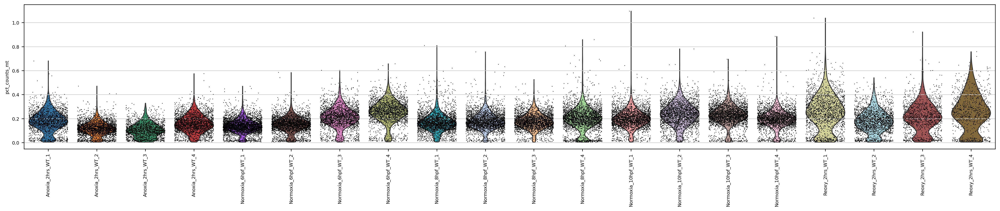

In [ ]:
sc.pl.violin(adata, ['pct_counts_mt'], jitter=0.4, groupby = 'sample', rotation = 90)

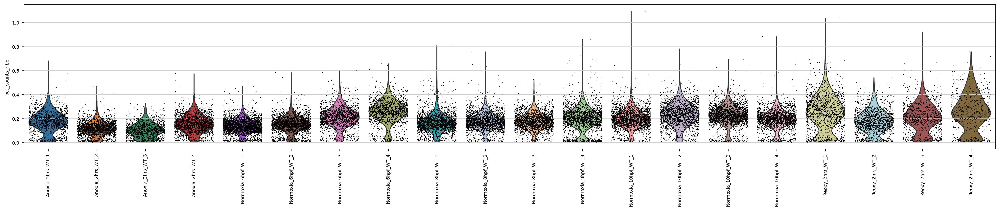

In [ ]:
sc.pl.violin(adata, ['pct_counts_ribo'], jitter=0.4, groupby = 'sample', rotation = 90)

In [ ]:
sc.set_figure_params(dpi=120, figsize=[10,4], fontsize=7)

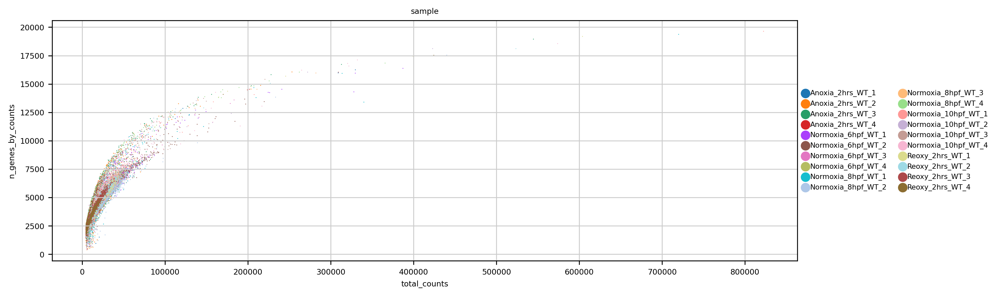

In [ ]:
sc.pl.scatter(adata, x = 'total_counts', y = 'n_genes_by_counts', color = 'sample')

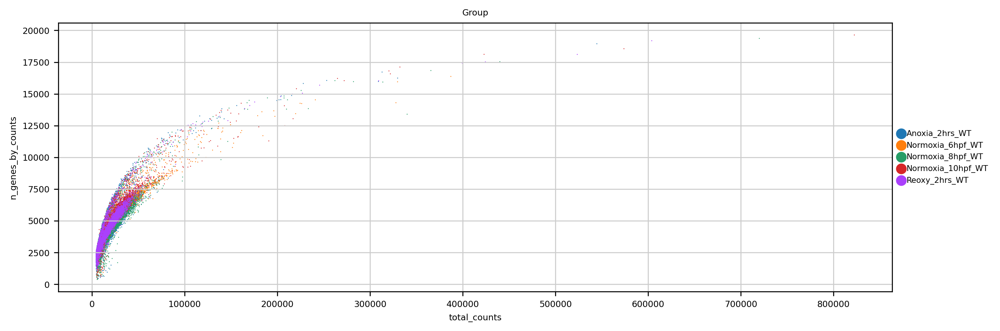

In [ ]:
sc.pl.scatter(adata, x = 'total_counts', y = 'n_genes_by_counts', color = 'Group')

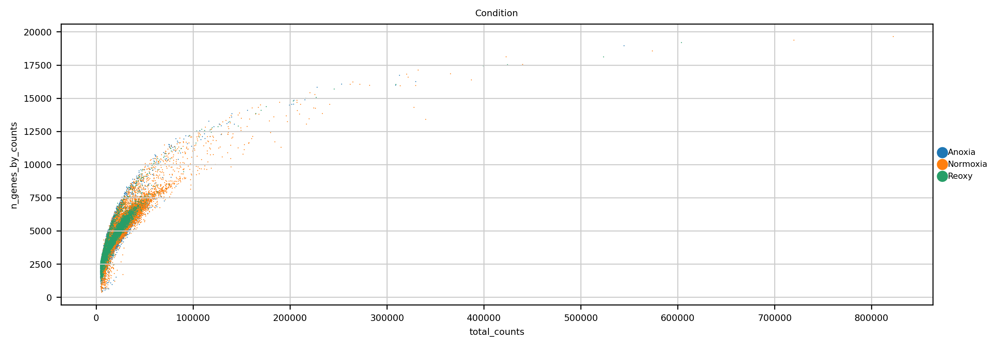

In [ ]:
sc.pl.scatter(adata, x = 'total_counts', y = 'n_genes_by_counts', color = 'Condition')

In [ ]:
#Save processed data to drive
adata.write(data_path + "h5ad/CPC_All_Preprocessed.h5ad", compression='gzip')

# Quick check post filtering

In this notebook, the following sections are simply to visualize any technical batch effects before proceeding

## Quick QC plots

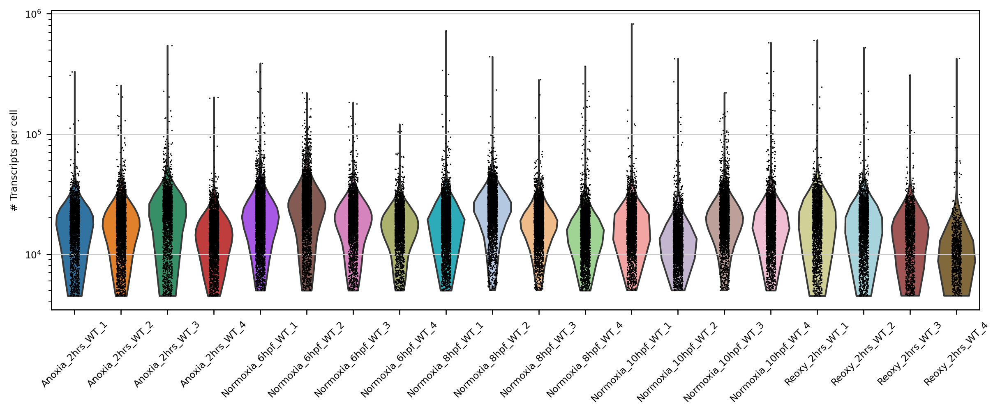

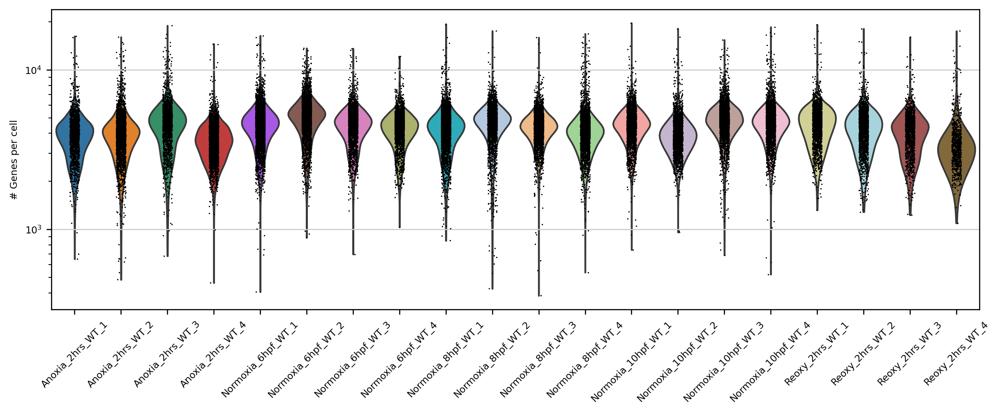

,UMI per Cell,Genes per Cell
Anoxia_2hrs_WT_1,19159.472656,4060.374625
Anoxia_2hrs_WT_2,19482.724609,4119.382872
Anoxia_2hrs_WT_3,24188.486328,4828.699045
Anoxia_2hrs_WT_4,15769.380859,3728.124956
Normoxia_10hpf_WT_1,19141.939453,4645.088662
Normoxia_10hpf_WT_2,14957.097656,4063.195201
Normoxia_10hpf_WT_3,22658.437500,4979.642857
Normoxia_10hpf_WT_4,20850.154297,4835.710526
Normoxia_6hpf_WT_1,23125.255859,4684.945358
Normoxia_6hpf_WT_2,28731.578125,5274.507170


In [ ]:
# Summarize # transcripts and genes detected per cell
sc.pl.violin(adata, 'total_counts', groupby='sample', xlabel='', ylabel='# Transcripts per cell', rotation=45, log=True)
sc.pl.violin(adata, 'n_genes_by_counts', groupby='sample', xlabel='', ylabel='# Genes per cell', rotation=45, log=True)
dew.get_sampling_stats(adata, groupby='sample')


In [ ]:
# Get the number of cells per sample
cell_counts_per_sample = adata.obs['sample'].value_counts()

# Print the result
print(cell_counts_per_sample)

sample
Normoxia_6hpf_WT_1     4319
Normoxia_10hpf_WT_3    3360
Normoxia_8hpf_WT_1     3343
Normoxia_8hpf_WT_2     3241
Normoxia_10hpf_WT_1    3237
Normoxia_8hpf_WT_3     3235
Normoxia_8hpf_WT_4     3216
Normoxia_6hpf_WT_2     3208
Anoxia_2hrs_WT_2       3176
Normoxia_10hpf_WT_4    3154
Anoxia_2hrs_WT_4       2865
Normoxia_10hpf_WT_2    2792
Normoxia_6hpf_WT_3     2589
Reoxy_2hrs_WT_2        2289
Normoxia_6hpf_WT_4     2262
Reoxy_2hrs_WT_1        2055
Anoxia_2hrs_WT_1       2002
Anoxia_2hrs_WT_3       1884
Reoxy_2hrs_WT_3        1419
Reoxy_2hrs_WT_4         858
Name: count, dtype: int64


## Process and Normalize

In [ ]:
adata.layers['raw_nolog'] = adata.X.copy()
adata.layers['raw'] = np.log1p(adata.X.copy())
sc.pp.normalize_total(adata, target_sum=1e6, inplace=True) # TPM Normalization
adata.layers['tpm_nolog'] = adata.X.copy()
adata.layers['tpm'] = np.log1p(adata.X.copy())
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, n_top_genes=2000, batch_key='batch')
sc.pp.scale(adata, zero_center=False)

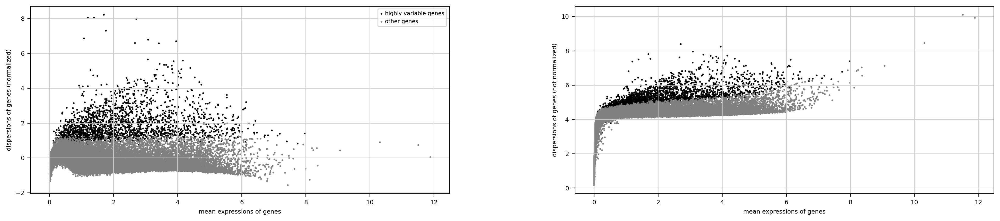

In [ ]:
#with top 2000 genes
sc.pl.highly_variable_genes(adata)

## Compute Embeddings and Perform Clustering



In [ ]:
sc.set_figure_params(dpi=120, figsize=[4,4], fontsize=7)

Performing PCA on data matrix
Performing PCA on randomized data matrices
Iteration 20 / 20

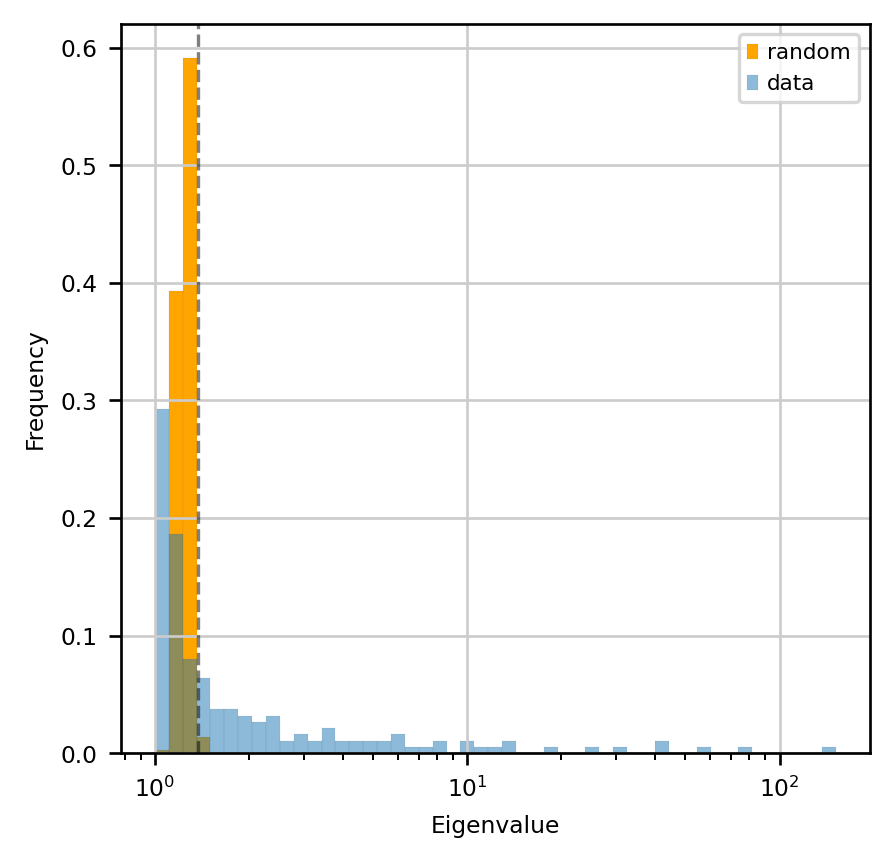

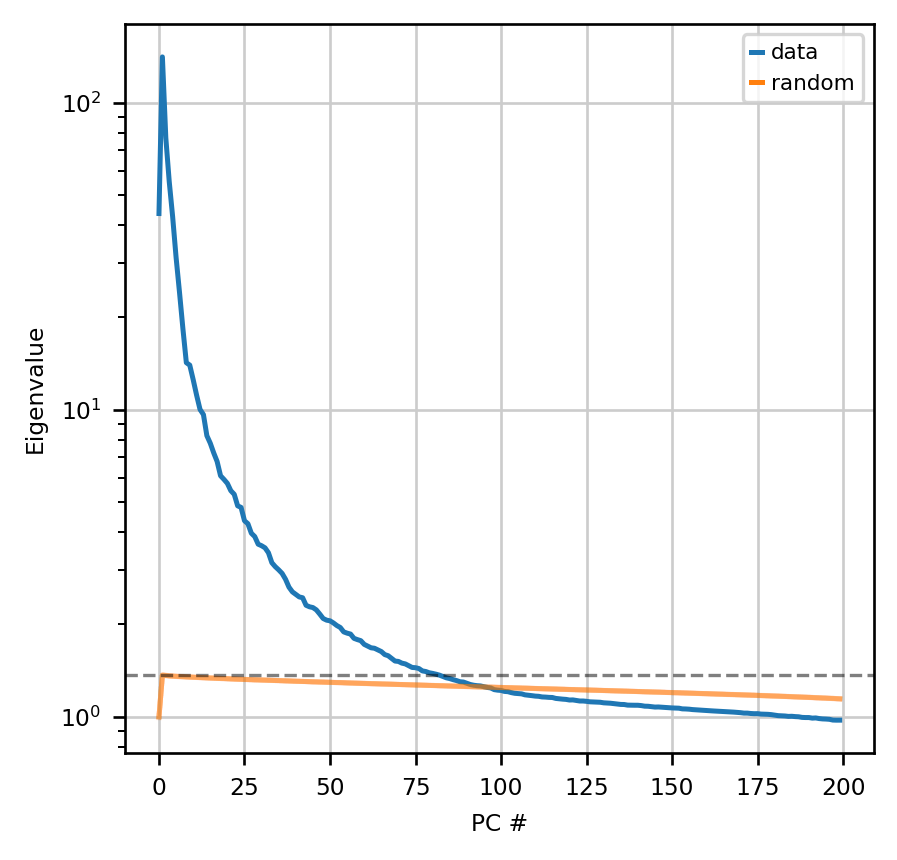

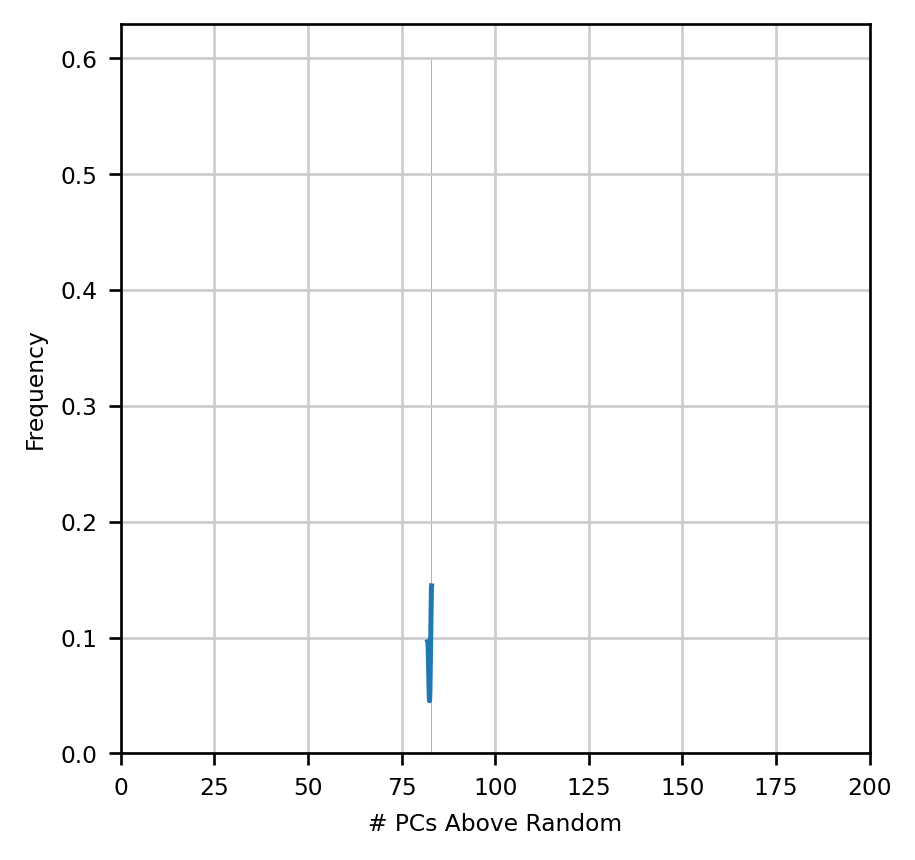

Counting the # of PCs with eigenvalues above random in >95% of trials
Eigenvalue Threshold = 1.37
# Significant PCs = 82


In [ ]:
# Determine # of significant PC dimensions
adata = dew.get_significant_pcs(adata, n_iter = 20, n_comps_test = 200, show_plots=True, zero_center=False)

In [ ]:
adata.uns['n_sig_PCs'] = 82

In [ ]:
# Perform PCA with a specified number of dimensions
sc.pp.pca(adata, n_comps=adata.uns['n_sig_PCs'])

In [ ]:
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=adata.uns['n_sig_PCs'], metric='euclidean')

In [ ]:
# Generate embedding
sc.tl.umap(adata, n_components=2, spread=1)

In [ ]:
# Perform graph clustering
sc.tl.leiden(adata, resolution=1) # default resolution = 1

## Plot Embeddings

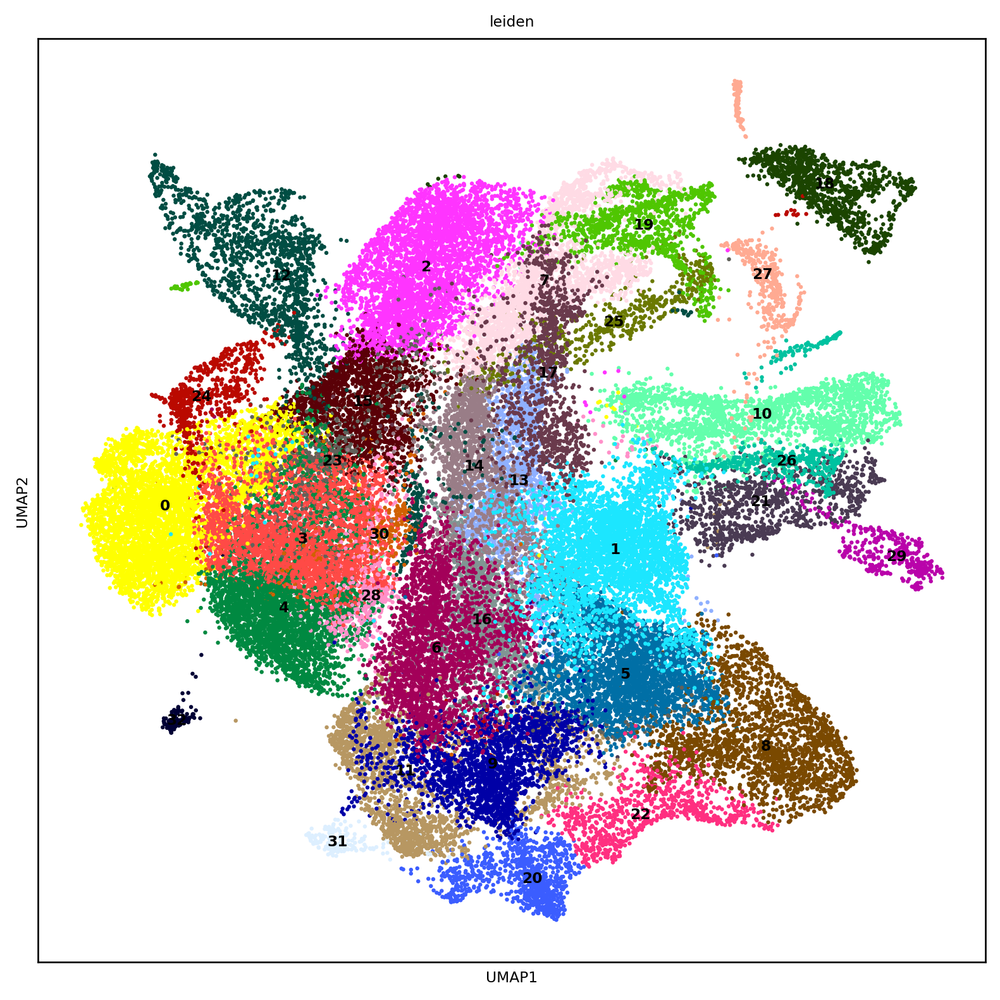

In [ ]:
sc.set_figure_params(dpi=120, figsize=[8,8], fontsize=7)
sc.pl.umap(adata, color=['leiden'], legend_loc='on data', size =15)

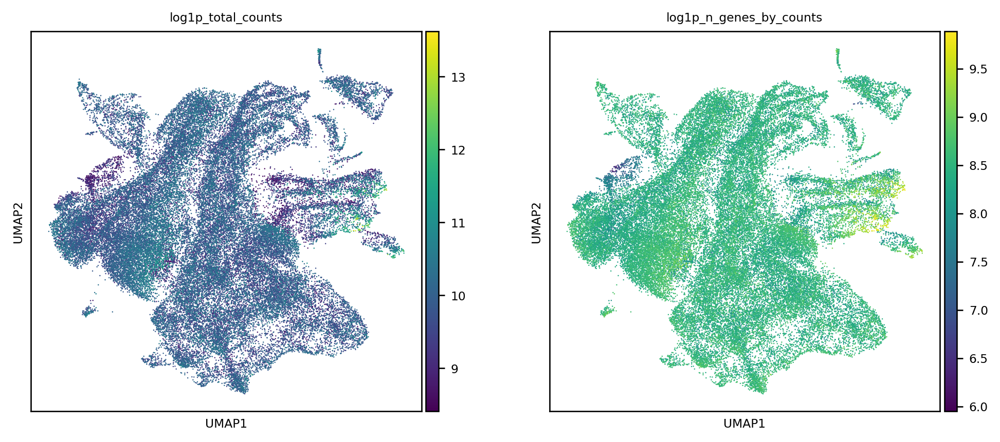

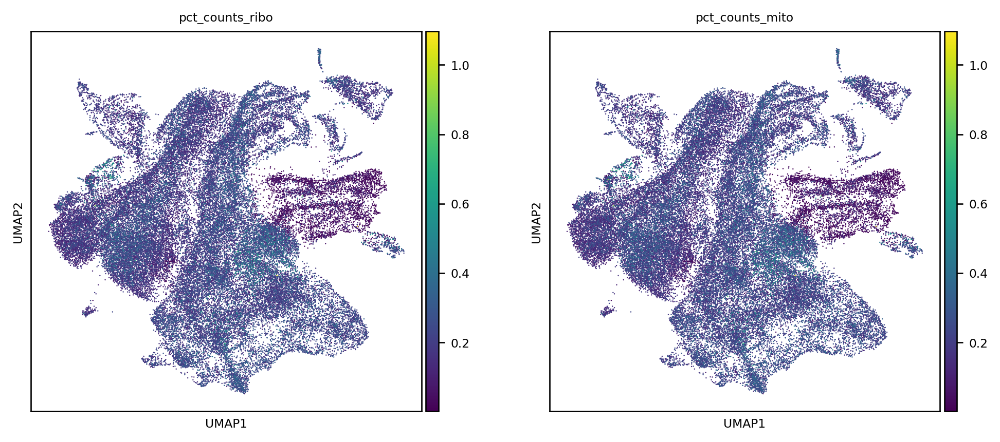

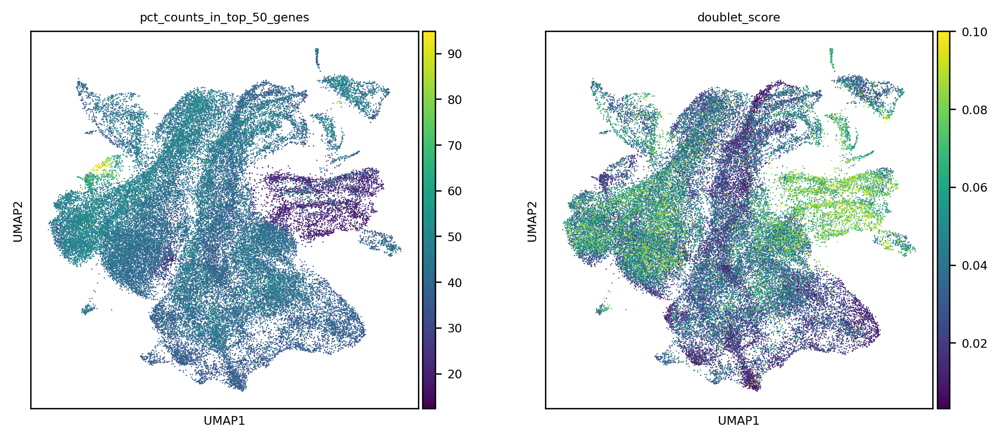

In [ ]:
sc.set_figure_params(dpi=120, figsize=[4,4], fontsize=7)
sc.pl.umap(adata, color=['log1p_total_counts','log1p_n_genes_by_counts'])
sc.pl.umap(adata, color=['pct_counts_ribo','pct_counts_mito'])
sc.pl.umap(adata, color=['pct_counts_in_top_50_genes', 'doublet_score'])